# Autonomous Cleaning Robot: Reinforcement Learning with Battery Management

## Project Overview

We train a Roomba-style vacuum cleaning robot using tabular reinforcement learning. The robot **cleans automatically as it moves**. Its real decisions are **where to go** and **when to recharge**.

### Key Design Choices
- **Auto-clean on move**: No explicit "Clean" action. Moving onto a dirty tile cleans it.
- **Partial observability**: The agent sees `(row, col, battery_bin)` but NOT the dirt grid. It must learn dirt patterns through reward signals.
- **Battery constraint**: 50 steps of battery on a 10x10 grid. The agent must learn to recharge without hard-coded heuristics.

### Research Questions
1. **Exploration strategies under battery constraint**: Which exploration method (Epsilon-Greedy, UCB, Optimistic Initialization) best handles the battery constraint?
2. **Q-Learning vs SARSA for risk-sensitive tasks**: Q-Learning (off-policy, optimistic) vs SARSA (on-policy, cautious) — which better manages catastrophic battery failure?

### Experiment Structure
- **Experiment 1**: Q-Learning with 3 exploration strategies — compare learning speed, coverage, and battery management
- **Experiment 2**: Best exploration strategy with Q-Learning vs SARSA — which algorithm handles battery risk better?
- **Experiment 3** (Phase 2): Scale up to realistic apartment with walls and doorways — charger at corner (0,0)
- **Experiment 4** (Phase 2): Same apartment, charger moved to hallway center (7,7) — does charger placement matter?

---
## Setup

In [ ]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline


sys.path.insert(0, '.')

from config import *
from environment import CleaningRobotEnv
from agents import QLearningAgent, SARSAAgent
from utils import (
    run_experiment, train_agent, create_agent, evaluate_agent,
    plot_learning_curves, plot_multi_metric, plot_coverage_heatmap,
    plot_battery_analysis, plot_evaluation_comparison, summary_table,
    plot_apartment_layout,
)


np.random.seed(42)

# Plot style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('Setup complete.')
print(f'Environment: {PHASE1_CONFIG["rows"]}x{PHASE1_CONFIG["cols"]} grid')
print(f'Battery capacity: {PHASE1_CONFIG["battery_capacity"]} steps')
print(f'Training episodes: {TRAINING_EPISODES}')
print(f'Random seeds: {SEEDS}')

Setup complete.
Environment: 10x10 grid
Battery capacity: 50 steps
Training episodes: 5000
Random seeds: [42, 123, 256, 789, 1024]


---
## Environment Demonstration

Let's first understand how the environment works before training any agents.

In [2]:
# Create environment and inspect initial state
env_demo = CleaningRobotEnv()
state = env_demo.reset(seed=42)

print(f'Environment: {env_demo}')
print(f'Initial state: {state}')
print(f'  -> (row={state[0]}, col={state[1]}, battery_bin={state[2]})')
print(f'State space size: {env_demo.num_states} states')
print(f'  -> {env_demo.rows} rows x {env_demo.cols} cols x {env_demo.battery_bins} battery bins')
print(f'Action space: {NUM_ACTIONS} actions — {ACTIONS}')
print(f'Total dirty tiles: {env_demo.total_dirty}')
print(f'Charger position: {env_demo.charger_pos}')
print()
print('Reward structure:')
for name, value in REWARDS.items():
    print(f'  {name:20s} = {value:+.1f}')

Environment: CleaningRobotEnv(10x10, battery=50/50, cleaned=0/99)
Initial state: (0, 0, 4)
  -> (row=0, col=0, battery_bin=4)
State space size: 500 states
  -> 10 rows x 10 cols x 5 battery bins
Action space: 5 actions — {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Charge'}
Total dirty tiles: 99
Charger position: (0, 0)

Reward structure:
  clean_dirty          = +10.0
  step_cost            = -0.1
  wall_hit             = -2.0
  charge_success       = +5.0
  charge_full          = -1.0
  charge_away          = -5.0
  battery_dead         = -50.0


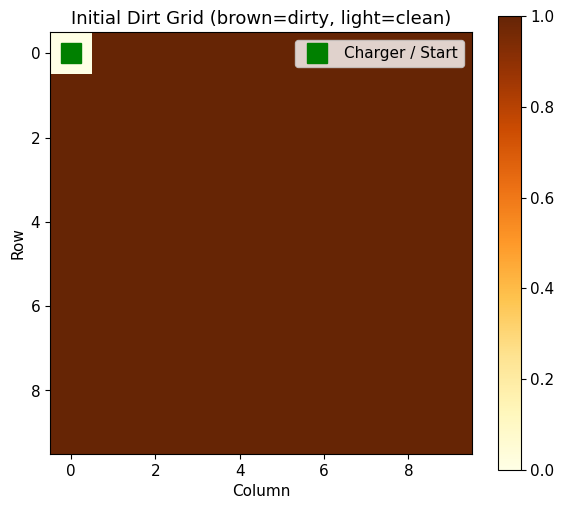

In [3]:
# Show initial dirt grid
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
dirt = env_demo.get_dirt_map()
im = ax.imshow(dirt, cmap='YlOrBr', vmin=0, vmax=1, origin='upper')
ax.set_title('Initial Dirt Grid (brown=dirty, light=clean)', fontsize=13)
ax.set_xlabel('Column')
ax.set_ylabel('Row')

# Mark charger and agent start
cr, cc = env_demo.charger_pos
ax.plot(cc, cr, 's', color='green', markersize=15, label='Charger / Start')
ax.legend(loc='upper right', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

---
## Experiment 1: Exploration Strategies Under Battery Constraint

We compare three exploration strategies, all using **Q-Learning**:

| Strategy | Description | Expected Behavior |
|----------|-------------|-------------------|
| **Epsilon-Greedy** | Random action with probability $\varepsilon$, decaying over time | Standard baseline. May waste battery on random moves early on. |
| **UCB** | Select action with highest $Q(s,a) + c\sqrt{\frac{\ln t}{N(s,a)}}$ | Systematic exploration. Tries all actions before exploiting. |
| **Optimistic Init** | Initialize $Q$-values high (15.0), use $\varepsilon$-greedy | Every action looks promising initially, agent tries everything. |

**Hypothesis**: UCB and Optimistic Initialization should learn battery management faster than Epsilon-Greedy, because they explore more systematically rather than randomly wasting battery.

In [5]:
# Experiment 1: Q-Learning with 3 exploration strategies
print('Running Experiment 1: Exploration Strategies (Q-Learning)')
print(f'Training for {TRAINING_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp1_results = {}
exp1_agents = {}

# Epsilon-Greedy
print('Training Q-Learning + Epsilon-Greedy...')
metrics_eg, agents_eg = run_experiment('qlearning', 'epsilon_greedy')
exp1_results['Q-Learning + ε-Greedy'] = metrics_eg
exp1_agents['Q-Learning + ε-Greedy'] = agents_eg
print('  Done.')

# UCB
print('Training Q-Learning + UCB...')
metrics_ucb, agents_ucb = run_experiment('qlearning', 'ucb')
exp1_results['Q-Learning + UCB'] = metrics_ucb
exp1_agents['Q-Learning + UCB'] = agents_ucb
print('  Done.')

# Optimistic Initialization
print('Training Q-Learning + Optimistic Init...')
metrics_opt, agents_opt = run_experiment('qlearning', 'optimistic')
exp1_results['Q-Learning + Optimistic'] = metrics_opt
exp1_agents['Q-Learning + Optimistic'] = agents_opt
print('  Done.')

print('\nExperiment 1 complete!')

Running Experiment 1: Exploration Strategies (Q-Learning)
Training for 5000 episodes x 5 seeds each...

Training Q-Learning + Epsilon-Greedy...
  Done.
Training Q-Learning + UCB...
  Done.
Training Q-Learning + Optimistic Init...
  Done.

Experiment 1 complete!


### Experiment 1: Results

In [6]:
# Summary table
print('=== Experiment 1: Final Performance (last 500 episodes) ===\n')
summary_table(exp1_results, last_n=500)

=== Experiment 1: Final Performance (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learning + ε-Greedy                    263.6      32.2%     50.4   100.0%      0.0
Q-Learning + UCB                         365.4      39.6%    230.0    60.0%     18.0
Q-Learning + Optimistic                  284.3      34.3%     50.1   100.0%      0.0
-------------------------------------------------------------------------------------


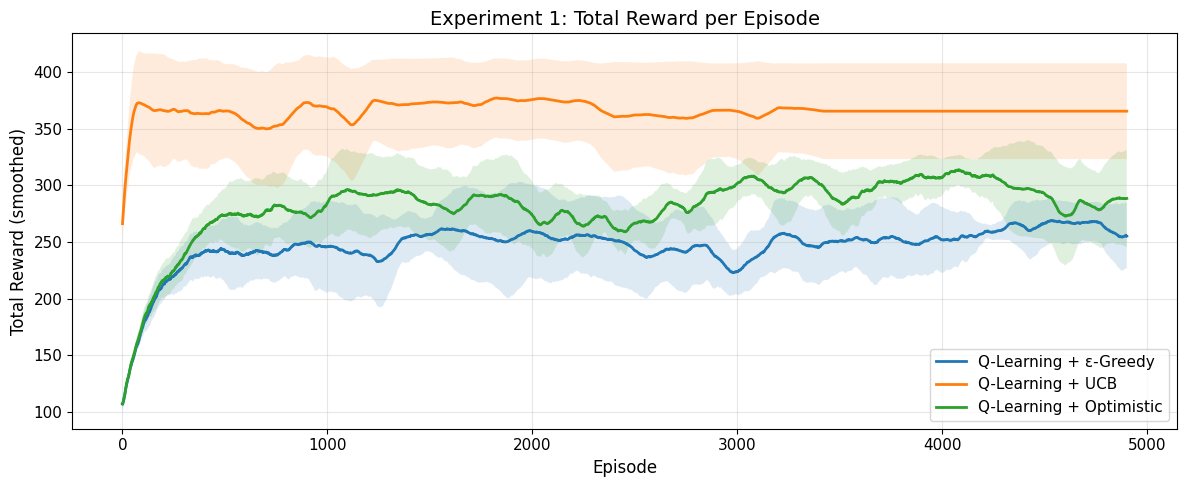

In [7]:
# Learning curves: reward
fig, ax = plot_learning_curves(
    exp1_results, metric='rewards', window=100,
    title='Experiment 1: Total Reward per Episode',
    ylabel='Total Reward (smoothed)',
)
plt.show()

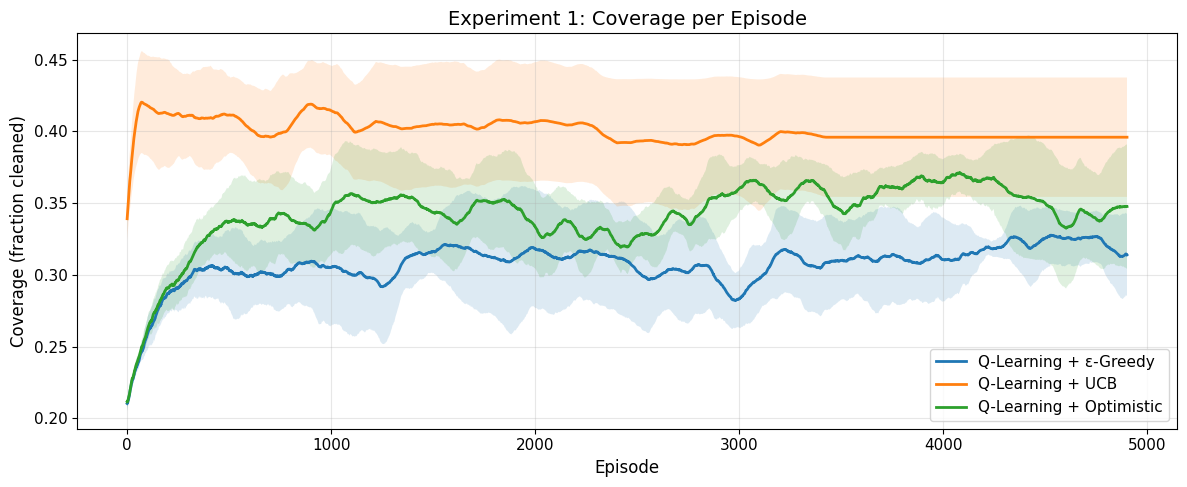

In [8]:
# Learning curves: coverage
fig, ax = plot_learning_curves(
    exp1_results, metric='coverages', window=100,
    title='Experiment 1: Coverage per Episode',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

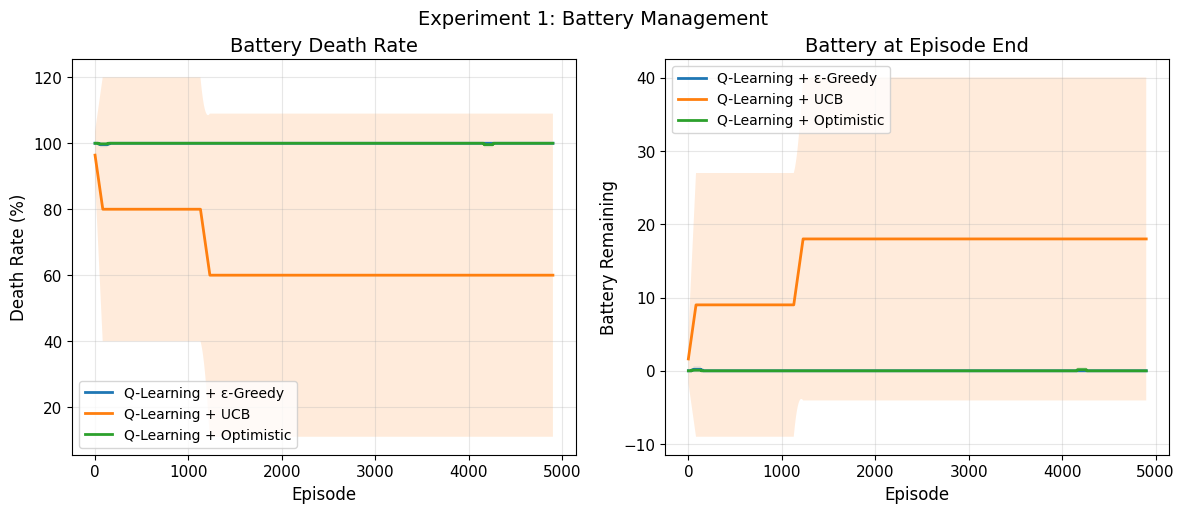

In [9]:
# Battery analysis: death rate and battery remaining
fig, axes = plot_battery_analysis(exp1_results, window=100)
fig.suptitle('Experiment 1: Battery Management', fontsize=14, y=1.02)
plt.show()

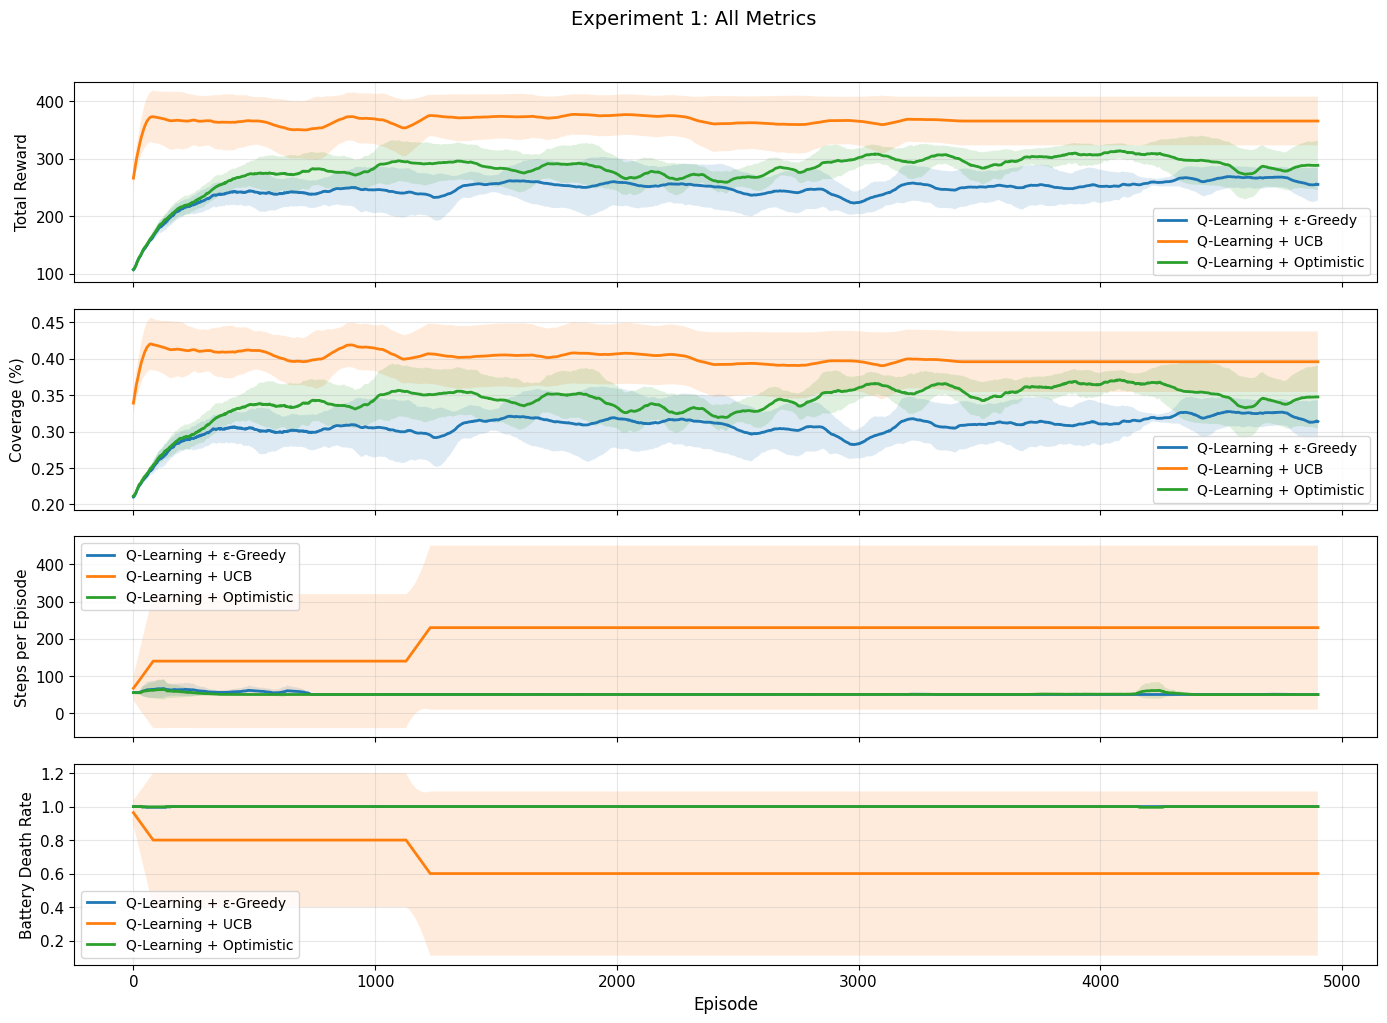

In [10]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp1_results, window=100)
fig.suptitle('Experiment 1: All Metrics', fontsize=14, y=1.02)
plt.show()

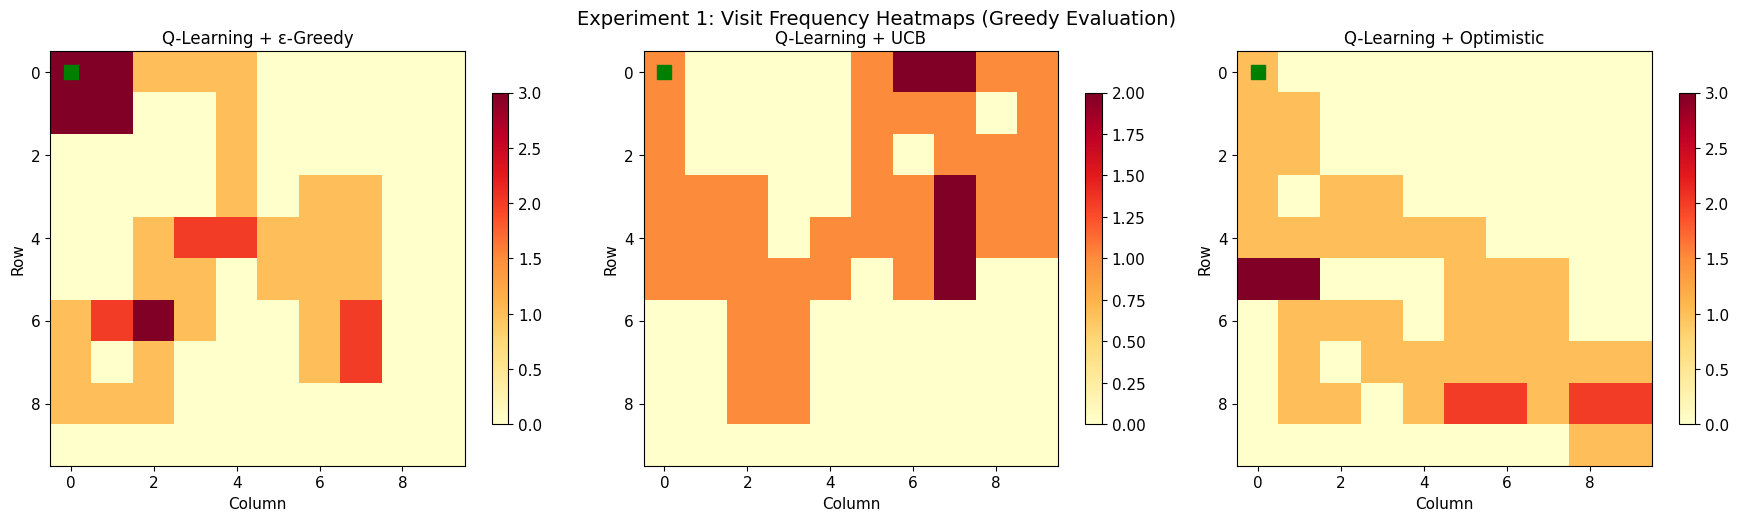

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, agents_list) in zip(axes, exp1_agents.items()):
    env_eval = CleaningRobotEnv()
    agent = agents_list[0]  # First seed's agent
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=1000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    im = ax.imshow(visit_counts, cmap='YlOrRd', origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='green', markersize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 1: Visit Frequency Heatmaps (Greedy Evaluation)', fontsize=14)
plt.tight_layout()
plt.show()

### Experiment 1: Analysis

**Winner: Q-Learning + UCB.**

From the last 500 training episodes:
- **UCB** reaches the best overall performance (**39.6% coverage**, **365.4 reward**) and is the only strategy that does *not* collapse into immediate battery death.
- **ε-greedy** and **optimistic init** both show **100% deaths** and episodes end around **~50 steps**, which is essentially “use the full battery and die” (no reliable return-and-charge behavior).

Why this happens:
- The environment has a strong asymmetric action: **Charge is only good at one location** (the charger) and is actively bad elsewhere (`charge_away = -5`). With naive exploration, the agent often learns “charging is bad” before it ever learns “charging at the charger is good”.
- **UCB forces trying under-visited actions**, which increases the chance of discovering successful charging behavior and enables longer episodes (230 steps avg vs ~50), hence higher coverage.

Takeaway: under a battery constraint, **the exploration strategy is a first-order design choice**—UCB is much more reliable here than ε-greedy or optimistic initialization.


---
## Experiment 2: Q-Learning vs SARSA (Risk-Sensitive Battery Management)

Using the best exploration strategy from Experiment 1, we now compare the two algorithms:

| Algorithm | Update Rule | Character |
|-----------|------------|----------|
| **Q-Learning** | $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$ | **Optimistic** — assumes it will take the best action next |
| **SARSA** | $Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma Q(s',a') - Q(s,a)]$ | **Cautious** — accounts for its own exploration noise |

**Hypothesis**: SARSA should be more conservative with battery because it accounts for the possibility of taking a bad (exploratory) action that wastes battery. Q-Learning might overestimate the value of being far from the charger because it assumes it will always take the optimal action to return.



In [ ]:
# Determine best exploration strategy from Experiment 1
print('Experiment 1 final coverages (last 500 episodes):')
best_label = None
best_coverage = -1

for label, all_metrics in exp1_results.items():
    avg_cov = np.mean([np.mean(m['coverages'][-500:]) for m in all_metrics])
    print(f'  {label}: {avg_cov*100:.1f}%')
    if avg_cov > best_coverage:
        best_coverage = avg_cov
        best_label = label

# Extract exploration strategy name
exploration_map = {
    'Q-Learning + ε-Greedy': 'epsilon_greedy',
    'Q-Learning + UCB': 'ucb',
    'Q-Learning + Optimistic': 'optimistic',
}
best_exploration = exploration_map[best_label]
print(f'\nBest exploration strategy: {best_label} ({best_coverage*100:.1f}% coverage)')
print(f'Using "{best_exploration}" for Experiment 2.')

Experiment 1 final coverages (last 500 episodes):
  Q-Learning + ε-Greedy: 32.2%
  Q-Learning + UCB: 39.6%
  Q-Learning + Optimistic: 34.3%

Best exploration strategy: Q-Learning + UCB (39.6% coverage)
Using "ucb" for Experiment 2.


In [ ]:
# Experiment 2: Q-Learning vs SARSA with best exploration
print(f'Running Experiment 2: Q-Learning vs SARSA (both with {best_exploration})')
print(f'Training for {TRAINING_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp2_results = {}
exp2_agents = {}

# Q-Learning 
ql_label = f'Q-Learning + {best_exploration}'
print(f'Training Q-Learning + {best_exploration}...')
metrics_ql, agents_ql = run_experiment('qlearning', best_exploration)
exp2_results[ql_label] = metrics_ql
exp2_agents[ql_label] = agents_ql
print('  Done.')

# SARSA
sarsa_label = f'SARSA + {best_exploration}'
print(f'Training SARSA + {best_exploration}...')
metrics_sarsa, agents_sarsa = run_experiment('sarsa', best_exploration)
exp2_results[sarsa_label] = metrics_sarsa
exp2_agents[sarsa_label] = agents_sarsa
print('  Done.')

print('\nExperiment 2 complete!')

Running Experiment 2: Q-Learning vs SARSA (both with ucb)
Training for 5000 episodes x 5 seeds each...

Training Q-Learning + ucb...
  Done.
Training SARSA + ucb...
  Done.

Experiment 2 complete!


### Experiment 2: Results

In [14]:
# Summary table
print('=== Experiment 2: Final Performance (last 500 episodes) ===\n')
summary_table(exp2_results, last_n=500)

=== Experiment 2: Final Performance (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learning + ucb                         365.4      39.6%    230.0    60.0%     18.0
SARSA + ucb                              404.6      44.9%    140.0    80.0%      4.0
-------------------------------------------------------------------------------------


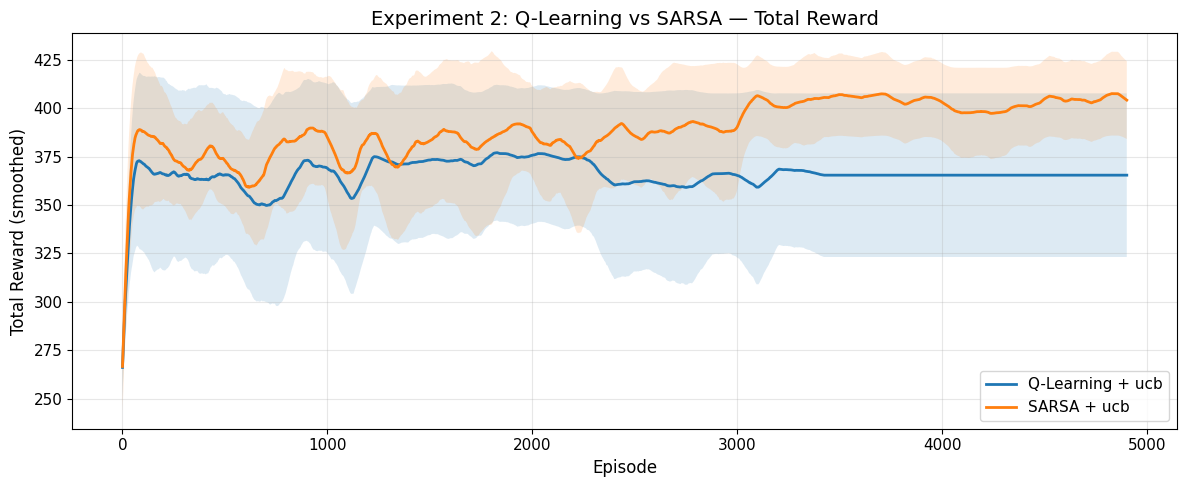

In [15]:
# Learning curves
fig, ax = plot_learning_curves(
    exp2_results, metric='rewards', window=100,
    title='Experiment 2: Q-Learning vs SARSA — Total Reward',
    ylabel='Total Reward (smoothed)',
)
plt.show()

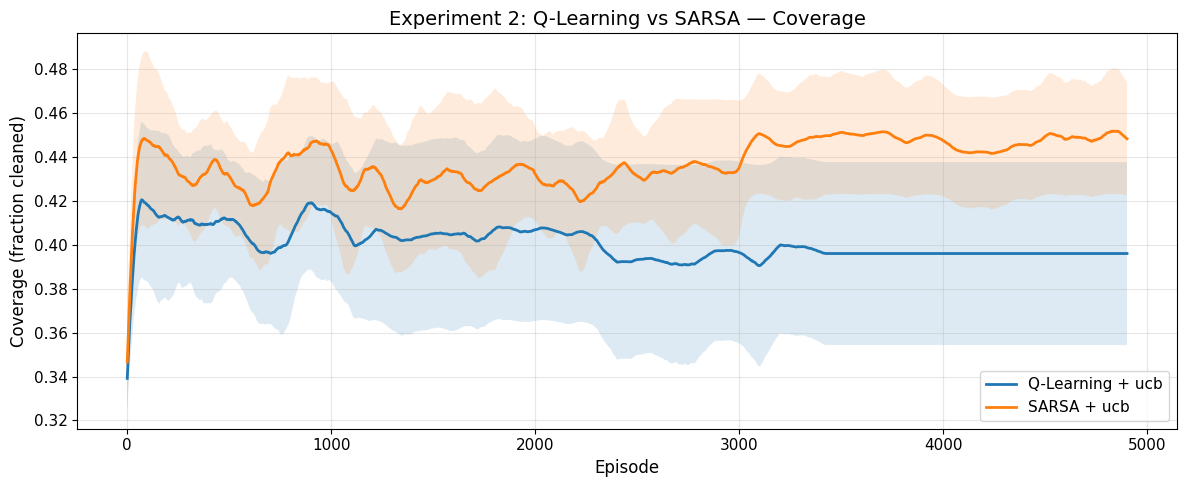

In [16]:
fig, ax = plot_learning_curves(
    exp2_results, metric='coverages', window=100,
    title='Experiment 2: Q-Learning vs SARSA — Coverage',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

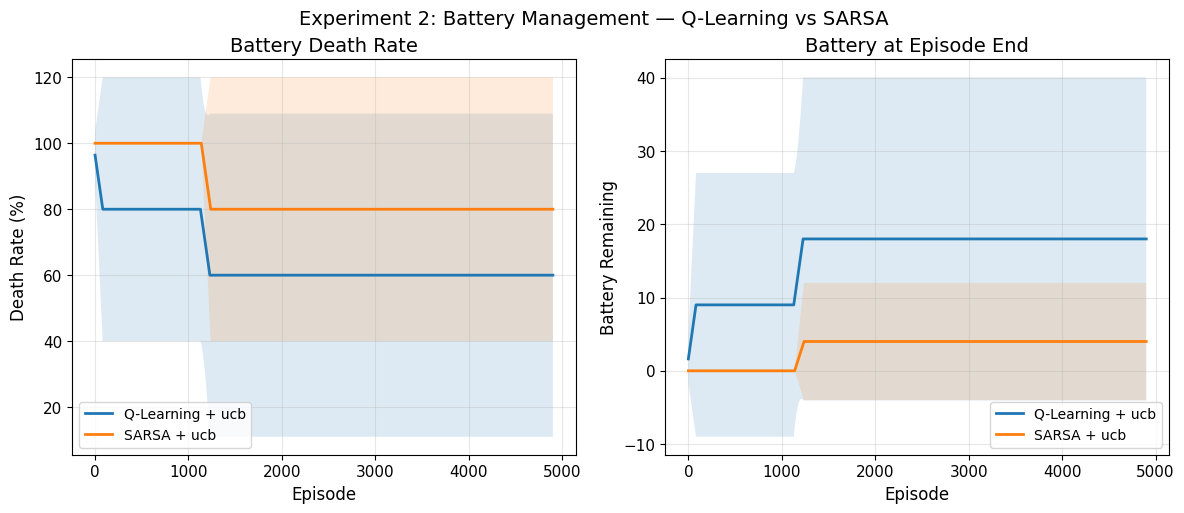

In [17]:
# Battery analysis
fig, axes = plot_battery_analysis(exp2_results, window=100)
fig.suptitle('Experiment 2: Battery Management — Q-Learning vs SARSA', fontsize=14, y=1.02)
plt.show()

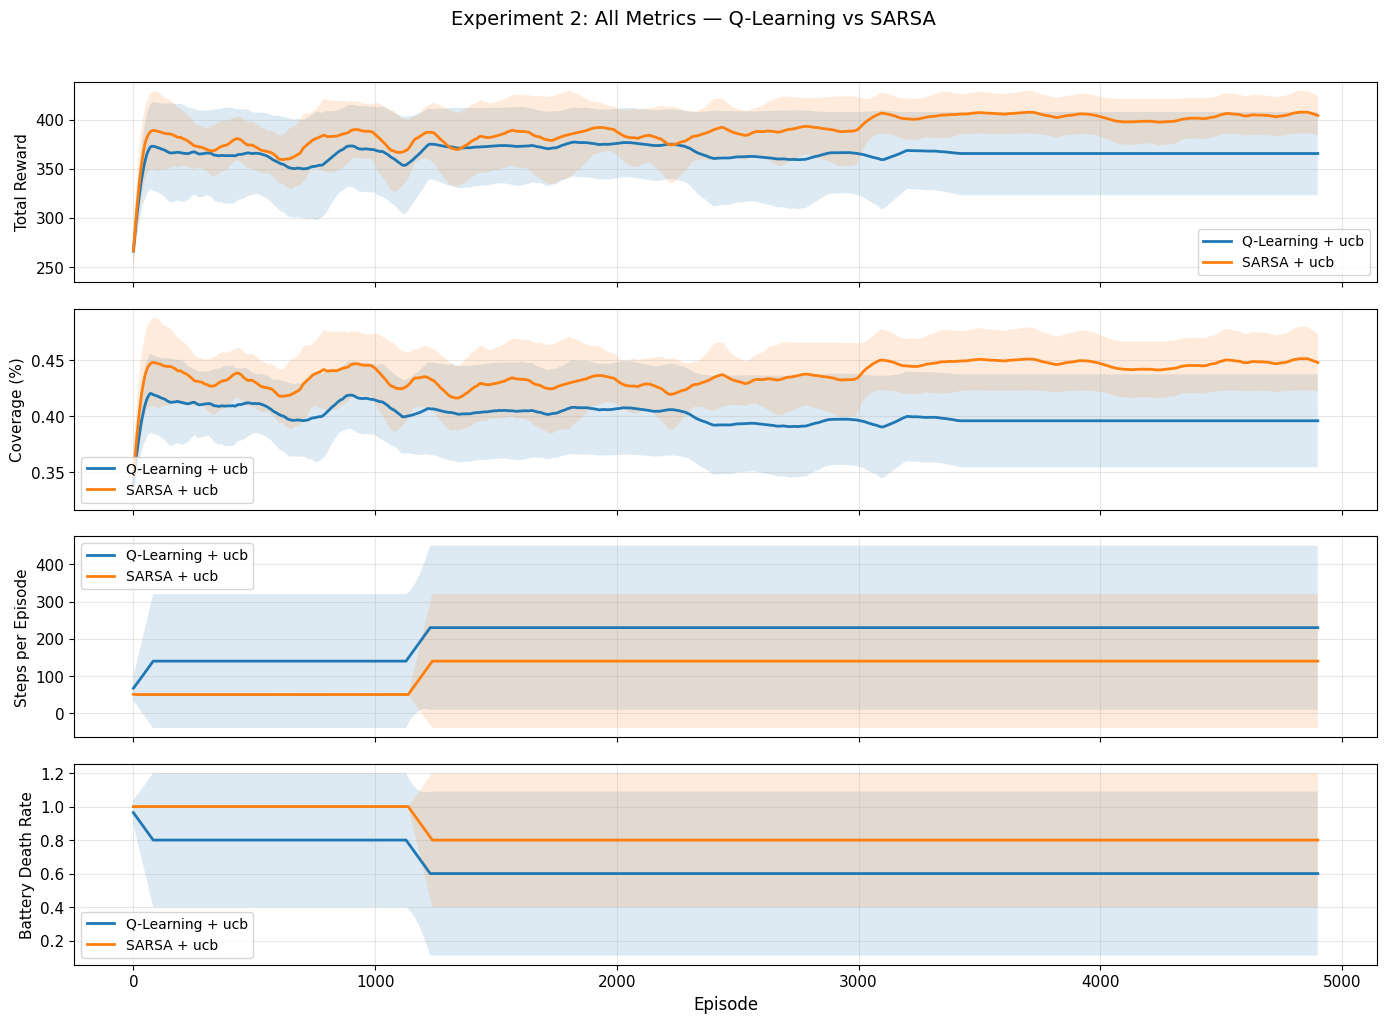

In [18]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp2_results, window=100)
fig.suptitle('Experiment 2: All Metrics — Q-Learning vs SARSA', fontsize=14, y=1.02)
plt.show()

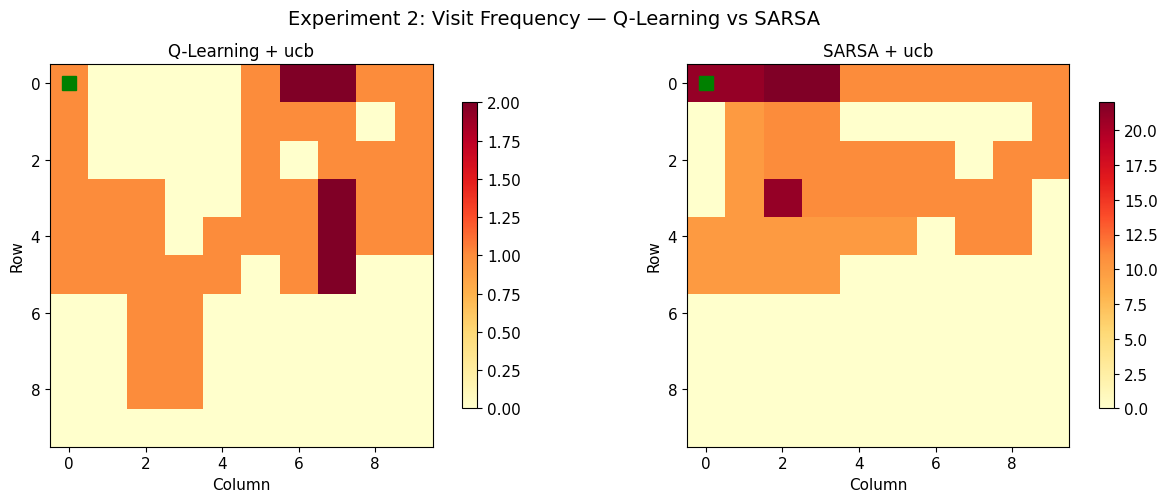

In [19]:
# Coverage heatmaps: Q-Learning vs SARSA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, agents_list) in zip(axes, exp2_agents.items()):
    env_eval = CleaningRobotEnv()
    agent = agents_list[0]
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=2000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    im = ax.imshow(visit_counts, cmap='YlOrRd', origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='green', markersize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 2: Visit Frequency — Q-Learning vs SARSA', fontsize=14)
plt.tight_layout()
plt.show()

### Experiment 2: Analysis

We compare **Q-Learning + UCB** vs **SARSA + UCB**.

Training (last 500 episodes):
- **SARSA + UCB** achieves higher performance (**404.6 reward**, **44.9% coverage**) and uses fewer steps (**140** vs **230**), but it has a *higher* training death rate (**80%** vs **60%**) and ends with less remaining battery.

Greedy evaluation (no exploration):
- In the evaluation printout, **SARSA has 0% deaths**, while the Q-Learning variants show frequent battery death.

Interpretation:
- The difference between training death-rate and greedy-eval death-rate highlights an important point: **training metrics are confounded by exploration** (especially for UCB). An agent can appear “safe” during training because exploration occasionally selects Charge, even if the learned greedy policy does not charge reliably.
- Overall, SARSA + UCB gives the best reward/coverage and (in greedy evaluation here) the most robust survival behavior.




---
## Greedy Evaluation

Evaluate the best trained agents with **no exploration** (purely greedy) to measure true learned performance.

In [20]:
# Evaluate all agents from both experiments
eval_results = {}

# Best agents from Experiment 1 (first seed)
for label, agents_list in exp1_agents.items():
    env_eval = CleaningRobotEnv()
    eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
    eval_results[label] = eval_metrics
    print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
          f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
          f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

# SARSA from Experiment 2
for label, agents_list in exp2_agents.items():
    if 'SARSA' in label:
        env_eval = CleaningRobotEnv()
        eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
        eval_results[label] = eval_metrics
        print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
              f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
              f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

Q-Learning + ε-Greedy: reward=298.6, coverage=35.4%, deaths=100%
Q-Learning + UCB: reward=399.6, coverage=45.5%, deaths=100%
Q-Learning + Optimistic: reward=359.2, coverage=42.4%, deaths=100%
SARSA + ucb: reward=415.1, coverage=41.4%, deaths=0%


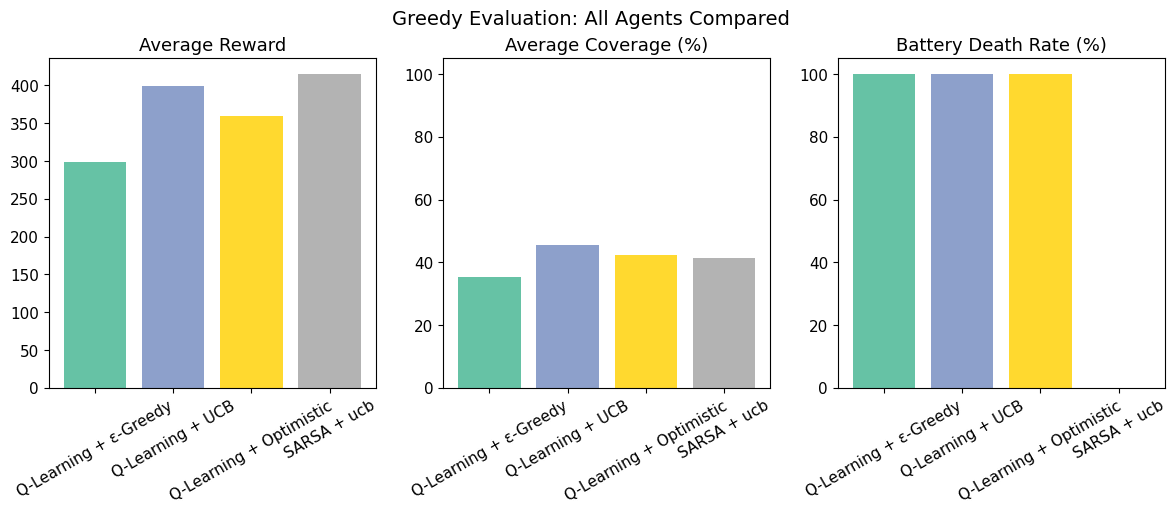

In [21]:
# Bar chart comparison
fig, axes = plot_evaluation_comparison(eval_results)
fig.suptitle('Greedy Evaluation: All Agents Compared', fontsize=14, y=1.02)
plt.show()

---
## Phase 2: Realistic Apartment

In Phase 2, we scale from a simple 10x10 open grid to a **realistic 15x15 apartment** with:
- **Walls** separating rooms (44 wall tiles)
- **Furniture** blocking movement (26 furniture tiles)
- **Narrow doorways** (1-tile gaps) connecting rooms
- **Increased battery** (80 steps) to compensate for the larger environment

### Room Layout
| Area | Location | Features |
|------|----------|----------|
| Living Room | Rows 0-5, Cols 0-6 | Charger at (0,0), couch, TV, coffee table |
| Kitchen | Rows 0-5, Cols 8-14 | Counter, fridge, table |
| Hallway | Rows 7-8, Cols 0-14 | Open corridor connecting top and bottom |
| Bedroom | Rows 10-14, Cols 0-6 | Bed, nightstand, wardrobe |
| Bathroom | Rows 10-14, Cols 8-11 | Bathtub, toilet, sink |
| Storage | Rows 10-14, Cols 13-14 | Shelves |

### Research Question
Do the rankings from Phase 1 (UCB > others, SARSA > Q-Learning) hold in a complex environment with narrow doorways and multiple rooms?

**Hypothesis**: UCB should gain an even bigger advantage because systematic exploration is critical for discovering paths between rooms through narrow doorways. SARSA should remain superior for battery management since the penalty for getting lost far from the charger is even more severe.

In [22]:
# Import the apartment layout visualization
from utils import plot_apartment_layout

# Create Phase 2 environment and visualize the layout
env_phase2 = CleaningRobotEnv(PHASE2_CONFIG)
env_phase2.reset(seed=42)

print(f'Phase 2 Environment: {env_phase2}')
print(f'Grid: {env_phase2.rows}x{env_phase2.cols}')
print(f'Battery capacity: {env_phase2.battery_capacity} steps')
print(f'Total tiles: {env_phase2.rows * env_phase2.cols}')
print(f'Wall tiles: {len(env_phase2.walls)}')
print(f'Furniture tiles: {len(env_phase2.furniture)}')
print(f'Blocked tiles: {len(env_phase2.blocked)}')
print(f'Walkable tiles: {len(env_phase2.walkable)}')
print(f'Cleanable (dirty) tiles: {env_phase2.total_dirty}')
print(f'State space: {env_phase2.num_states} states')
print(f'  ({env_phase2.rows} rows x {env_phase2.cols} cols x {env_phase2.battery_bins} battery bins)')
print(f'Charger position: {env_phase2.charger_pos}')

Phase 2 Environment: CleaningRobotEnv(15x15, battery=80/80, cleaned=0/154)
Grid: 15x15
Battery capacity: 80 steps
Total tiles: 225
Wall tiles: 44
Furniture tiles: 26
Blocked tiles: 70
Walkable tiles: 155
Cleanable (dirty) tiles: 154
State space: 1125 states
  (15 rows x 15 cols x 5 battery bins)
Charger position: (0, 0)


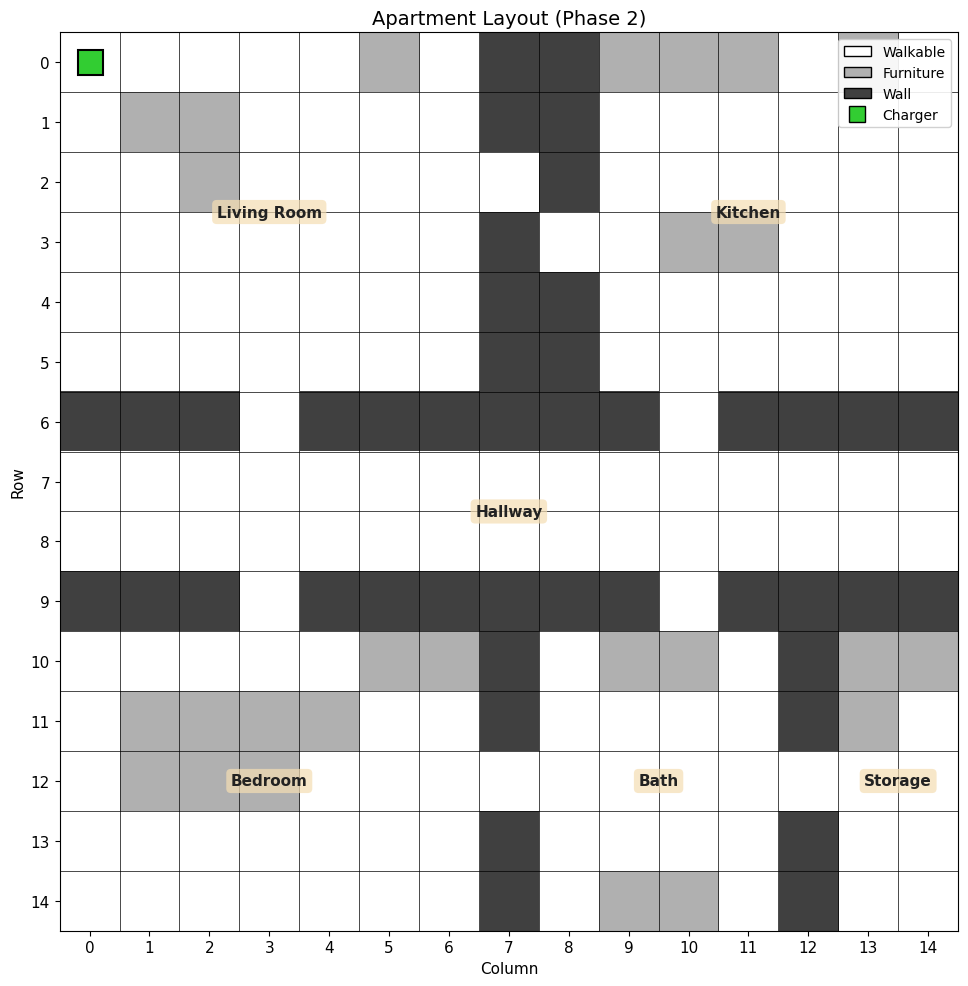

In [23]:
# Visualize the apartment layout
fig, ax = plot_apartment_layout(env_phase2, figsize=(10, 10))
plt.show()

### Experiment 3: Exploration Strategies in the Apartment (Corner Charger)

We re-run all three exploration strategies (Q-Learning) and the best algorithm comparison (SARSA + UCB) on the apartment layout with the charger at corner (0,0). We use **10,000 episodes** (doubled from Phase 1) because the larger state space requires more training.

In [ ]:
# Experiment 3: All exploration strategies + SARSA on apartment
PHASE2_EPISODES = 10000

print('Running Experiment 3: Phase 2 Apartment (charger at corner)')
print(f'Training for {PHASE2_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp3_results = {}
exp3_agents = {}

# Q-Learning + Epsilon-Greedy
print('Training Q-Learning + Epsilon-Greedy (apartment)...')
metrics, agents = run_experiment('qlearning', 'epsilon_greedy', config=PHASE2_CONFIG, num_episodes=PHASE2_EPISODES)
exp3_results['Q-Learn + ε-Greedy'] = metrics
exp3_agents['Q-Learn + ε-Greedy'] = agents
print('  Done.')

# Q-Learning + UCB
print('Training Q-Learning + UCB (apartment)...')
metrics, agents = run_experiment('qlearning', 'ucb', config=PHASE2_CONFIG, num_episodes=PHASE2_EPISODES)
exp3_results['Q-Learn + UCB'] = metrics
exp3_agents['Q-Learn + UCB'] = agents
print('  Done.')

# Q-Learning + Optimistic Init
print('Training Q-Learning + Optimistic (apartment)...')
metrics, agents = run_experiment('qlearning', 'optimistic', config=PHASE2_CONFIG, num_episodes=PHASE2_EPISODES)
exp3_results['Q-Learn + Optimistic'] = metrics
exp3_agents['Q-Learn + Optimistic'] = agents
print('  Done.')

# SARSA + UCB
print('Training SARSA + UCB (apartment)...')
metrics, agents = run_experiment('sarsa', 'ucb', config=PHASE2_CONFIG, num_episodes=PHASE2_EPISODES)
exp3_results['SARSA + UCB'] = metrics
exp3_agents['SARSA + UCB'] = agents
print('  Done.')

print('\nExperiment 3 complete!')

Running Experiment 3: Phase 2 Apartment (charger at corner)
Training for 10000 episodes x 5 seeds each...

Training Q-Learning + Epsilon-Greedy (apartment)...
  Done.
Training Q-Learning + UCB (apartment)...
  Done.
Training Q-Learning + Optimistic (apartment)...
  Done.
Training SARSA + UCB (apartment)...
  Done.

Experiment 3 complete!


### Experiment 3: Results

In [25]:
# Summary table
print('=== Experiment 3: Final Performance — Apartment (last 500 episodes) ===\n')
summary_table(exp3_results, last_n=500)

=== Experiment 3: Final Performance — Apartment (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learn + ε-Greedy                       264.9      20.4%    264.4    58.0%     18.2
Q-Learn + UCB                            375.3      26.2%    332.0    40.0%     28.8
Q-Learn + Optimistic                     290.8      22.8%    118.7    95.4%      1.6
SARSA + UCB                              404.9      28.7%    248.0    60.0%     13.4
-------------------------------------------------------------------------------------


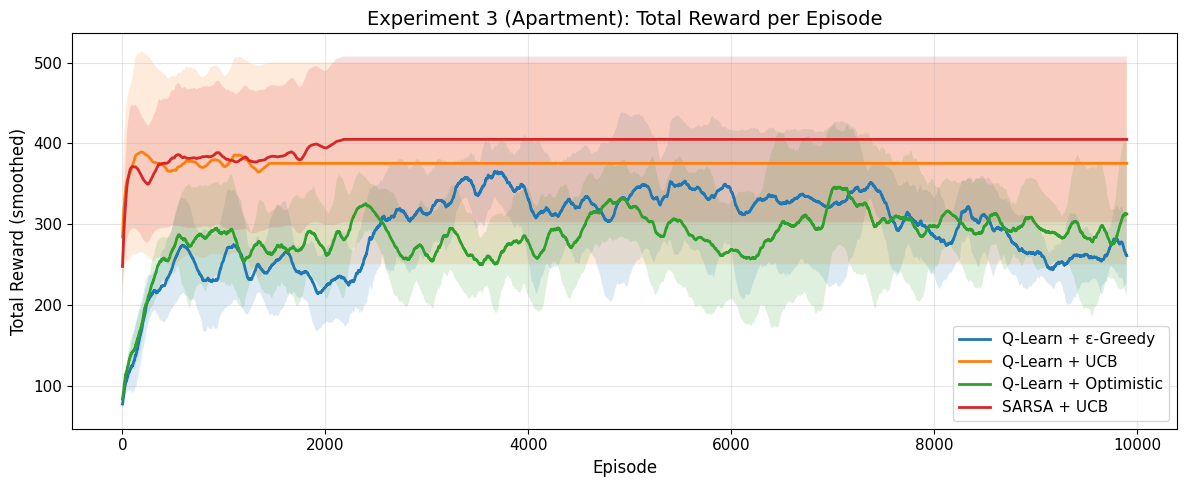

In [26]:
# Learning curves: reward
fig, ax = plot_learning_curves(
    exp3_results, metric='rewards', window=100,
    title='Experiment 3 (Apartment): Total Reward per Episode',
    ylabel='Total Reward (smoothed)',
)
plt.show()

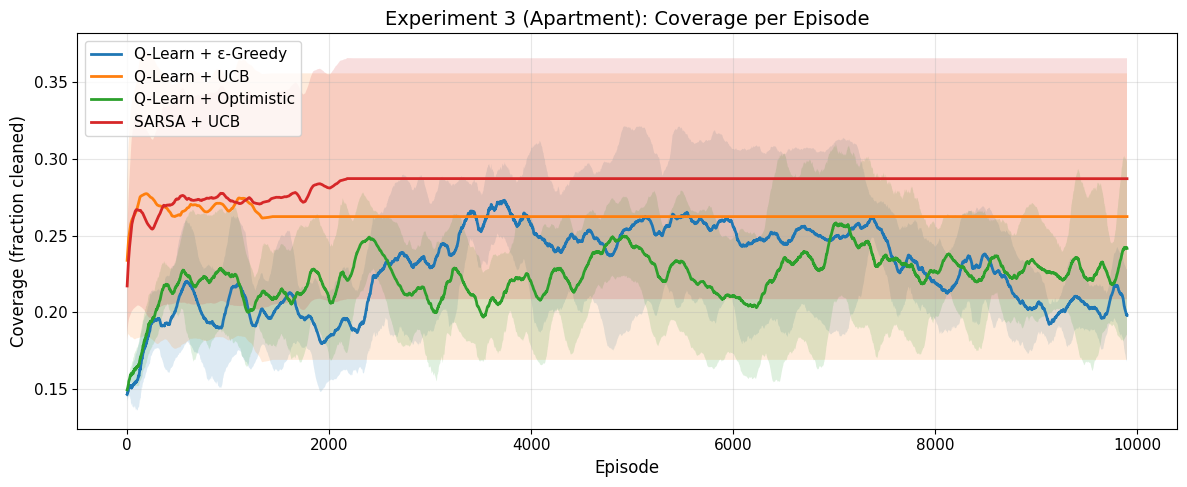

In [27]:
# Learning curves: coverage
fig, ax = plot_learning_curves(
    exp3_results, metric='coverages', window=100,
    title='Experiment 3 (Apartment): Coverage per Episode',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

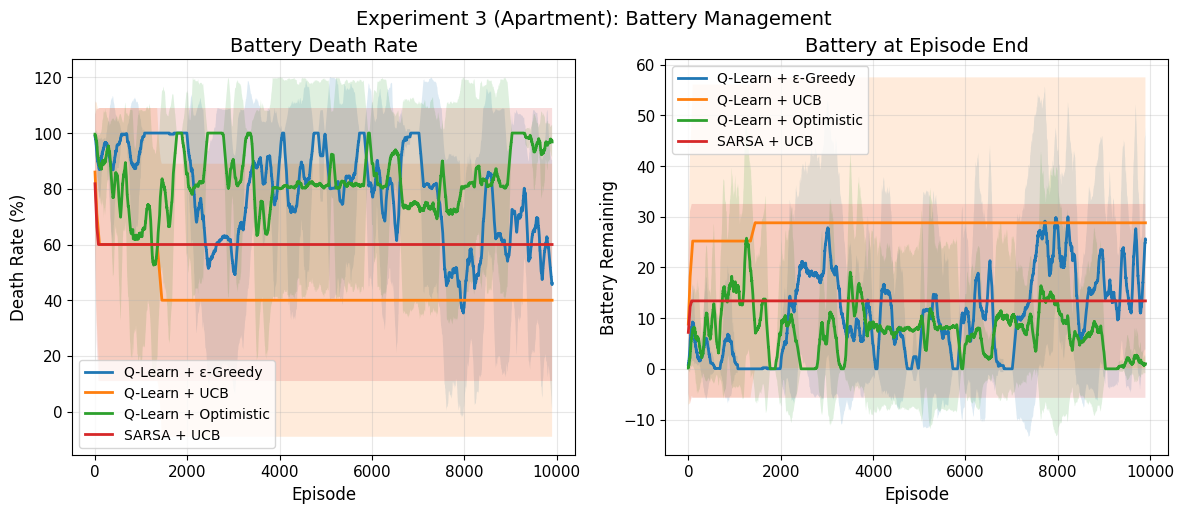

In [28]:
# Battery analysis
fig, axes = plot_battery_analysis(exp3_results, window=100)
fig.suptitle('Experiment 3 (Apartment): Battery Management', fontsize=14, y=1.02)
plt.show()

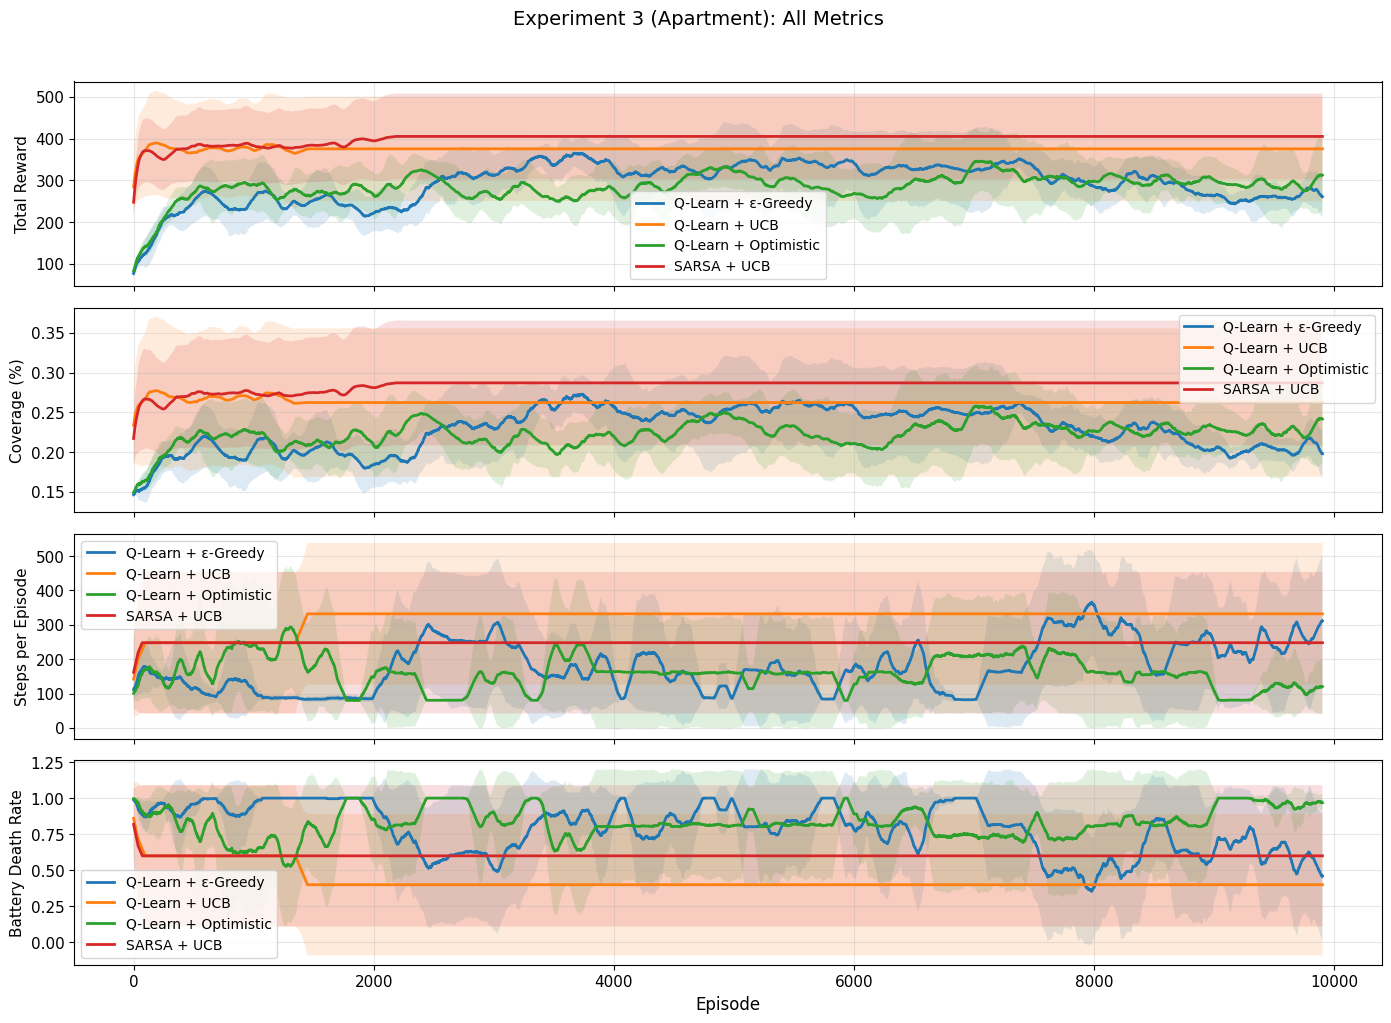

In [29]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp3_results, window=100)
fig.suptitle('Experiment 3 (Apartment): All Metrics', fontsize=14, y=1.02)
plt.show()

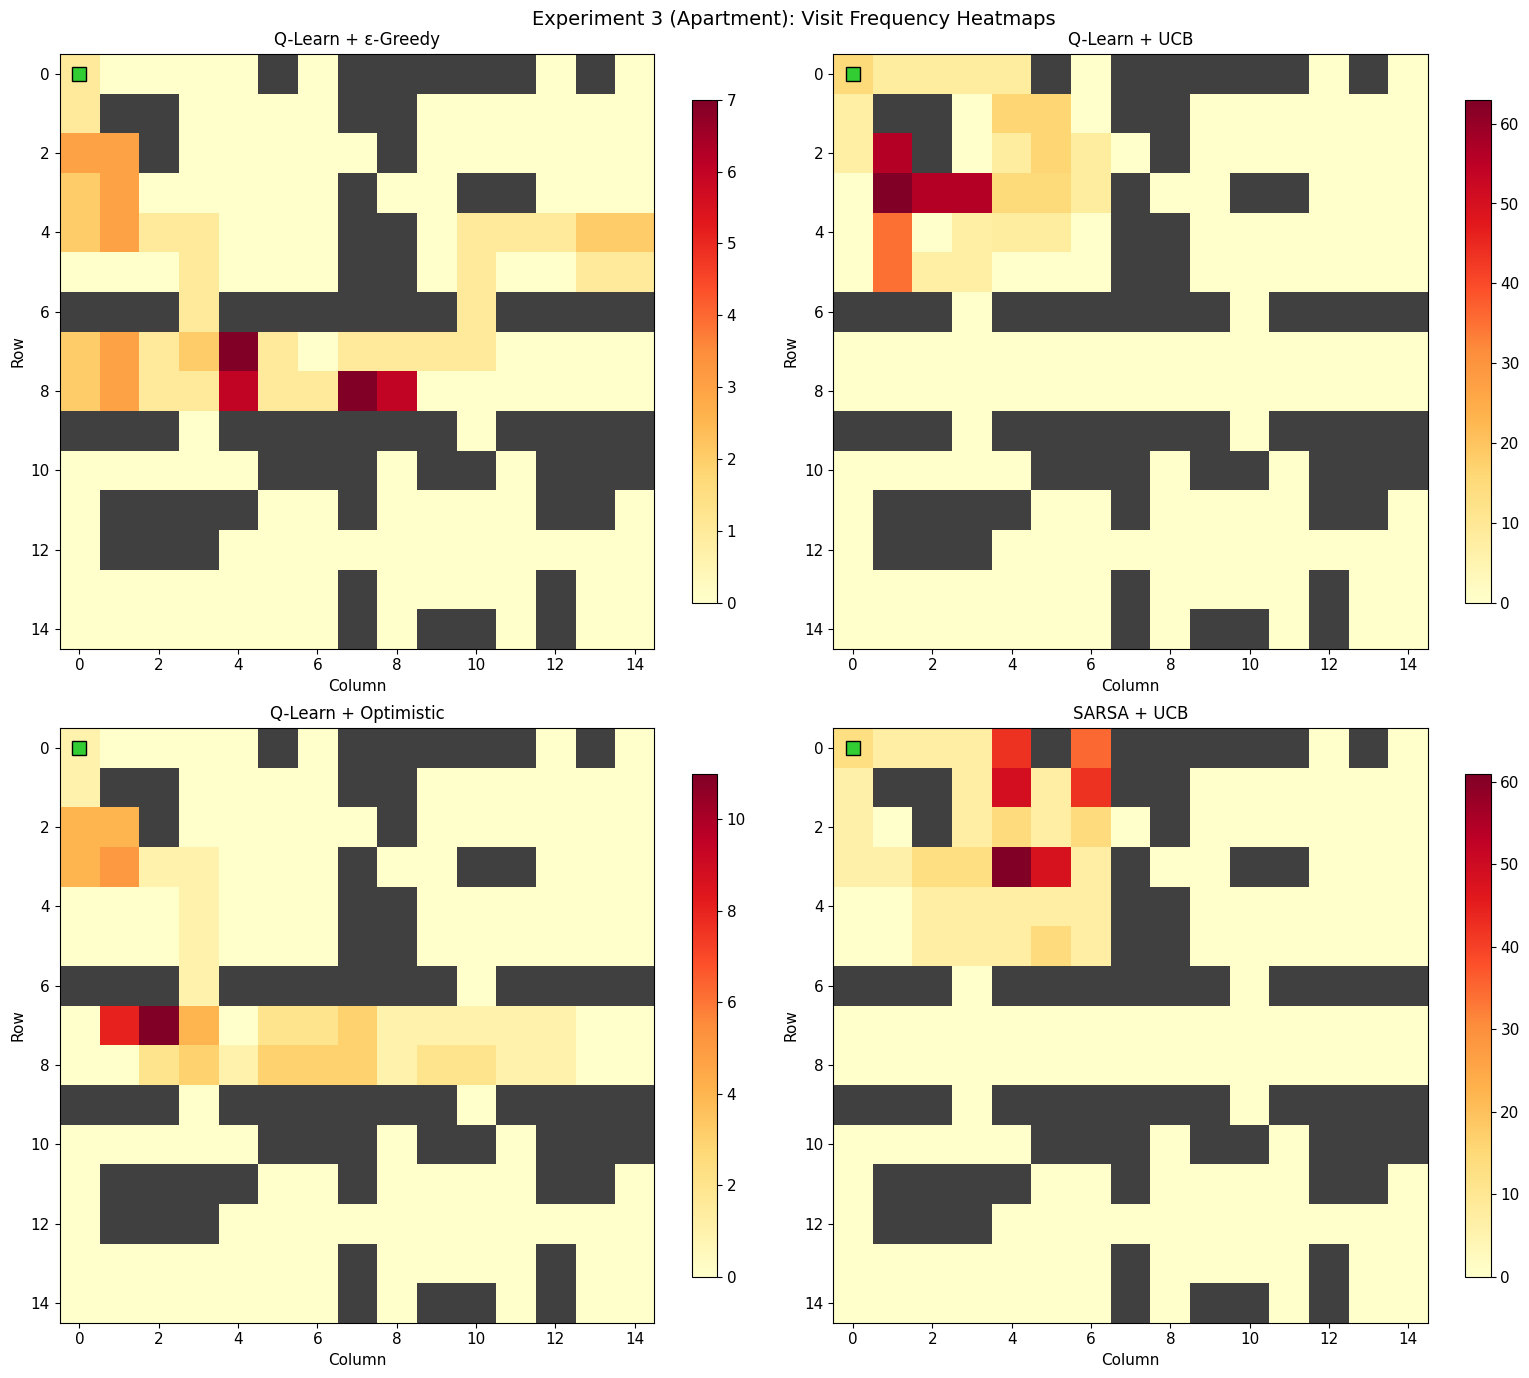

In [30]:
# Coverage heatmaps for all strategies on the apartment
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for ax, (label, agents_list) in zip(axes_flat, exp3_agents.items()):
    env_eval = CleaningRobotEnv(PHASE2_CONFIG)
    agent = agents_list[0]  # First seed's agent
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=5000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    # Mask blocked tiles so they show as distinct
    masked = np.ma.array(visit_counts)
    for (r, c) in env_eval.blocked:
        masked[r, c] = np.ma.masked
    
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='#404040')  # Blocked tiles in dark gray
    
    im = ax.imshow(masked, cmap=cmap, origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='limegreen', markersize=10, markeredgecolor='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 3 (Apartment): Visit Frequency Heatmaps', fontsize=14)
plt.tight_layout()
plt.show()

### Greedy Evaluation — Phase 2

In [31]:
# Greedy evaluation of Phase 2 agents
eval_results_p2 = {}

for label, agents_list in exp3_agents.items():
    env_eval = CleaningRobotEnv(PHASE2_CONFIG)
    eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
    eval_results_p2[label] = eval_metrics
    print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
          f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
          f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

Q-Learn + ε-Greedy: reward=336.0, coverage=25.3%, deaths=100%
Q-Learn + UCB: reward=238.2, coverage=16.2%, deaths=0%
Q-Learn + Optimistic: reward=265.3, coverage=20.8%, deaths=100%
SARSA + UCB: reward=303.8, coverage=20.8%, deaths=0%


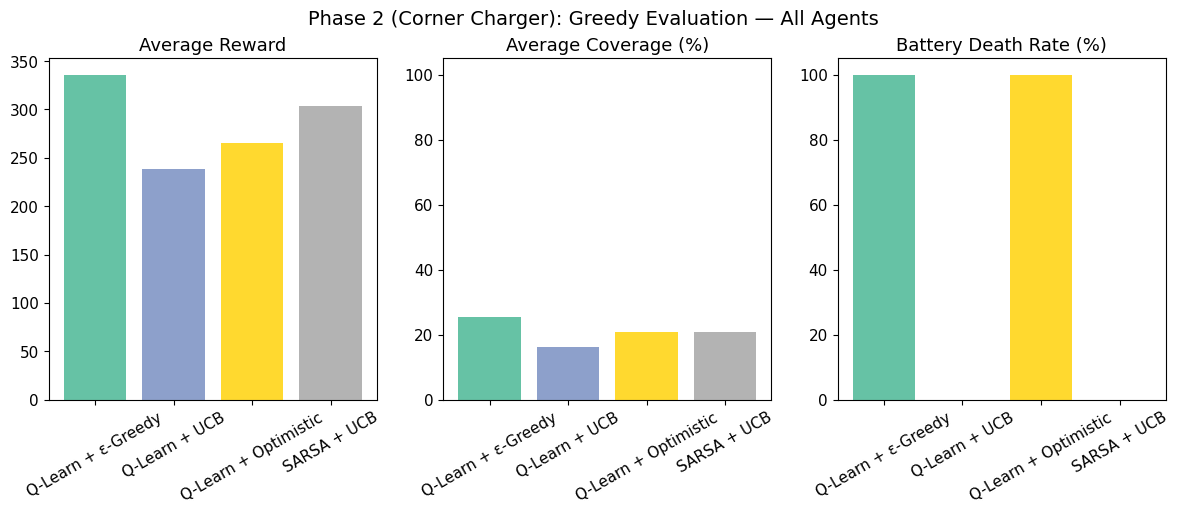

In [32]:
# Bar chart comparison — Phase 2
fig, axes = plot_evaluation_comparison(eval_results_p2)
fig.suptitle('Phase 2 (Corner Charger): Greedy Evaluation — All Agents', fontsize=14, y=1.02)
plt.show()

### Experiment 3: Analysis

**Setting:** realistic 15×15 apartment with walls/doorways, charger in the corner.

Training (last 500 episodes):
- Rankings still broadly match Phase 1: **UCB helps a lot**, and **SARSA + UCB** achieves the best reward/coverage (**404.9 reward**, **28.7% coverage**).
- **Q-Learn + UCB** is the most survival-friendly in training (**40% deaths**, highest remaining battery), but it is also slower/higher-step on average.
- **Optimistic init** performs poorly on safety (≈ **95% deaths**), suggesting optimism is not enough to learn the recharge affordance in this constrained layout.

Greedy evaluation:
- **UCB-trained agents can survive** here: both **Q-Learn + UCB** and **SARSA + UCB** show **0% deaths** in evaluation, while ε-greedy/optimistic still die.
- There is a survival/coverage trade-off: **Q-Learn + UCB** survives but cleans less (lower coverage), while **SARSA + UCB** achieves higher cleaning performance with survival.

Takeaway: once the environment has bottlenecks (doorways), **structured exploration + on-policy learning** is a strong combination for both coverage and survivability.


---
## Experiment 4: Charger Placement — Corner vs Hallway

Experiment 3 showed that agents with the charger at corner (0,0) tend to stay near the charger and fail to explore distant rooms. This is because the corner placement creates an **asymmetric** environment — returning from far rooms costs many steps.

We now test with the **charger at hallway center (7,7)**, which gives **symmetric access** to all rooms through the two doorways at row 6 and row 9.

### Controlled Comparison
| Variable | Experiment 3 | Experiment 4 |
|----------|-------------|-------------|
| Grid | 15x15 apartment | 15x15 apartment (identical) |
| Walls/Furniture | Same | Same |
| Battery | 80 | 80 |
| Charger | **(0, 0)** corner | **(7, 7)** hallway center |
| Episodes | 10,000 | 10,000 |
| Seeds | [42, 123, 256, 789, 1024] | Same |

**Hypothesis**: With a central charger, agents should achieve higher coverage because they can reach any room and return to charge with fewer steps.

Phase 2 (Hallway Charger): CleaningRobotEnv(15x15, battery=80/80, cleaned=0/154)
Charger position: (7, 7)  (hallway center)
Start position:   (7, 7)
Dirty tiles:      154
State space:      1125



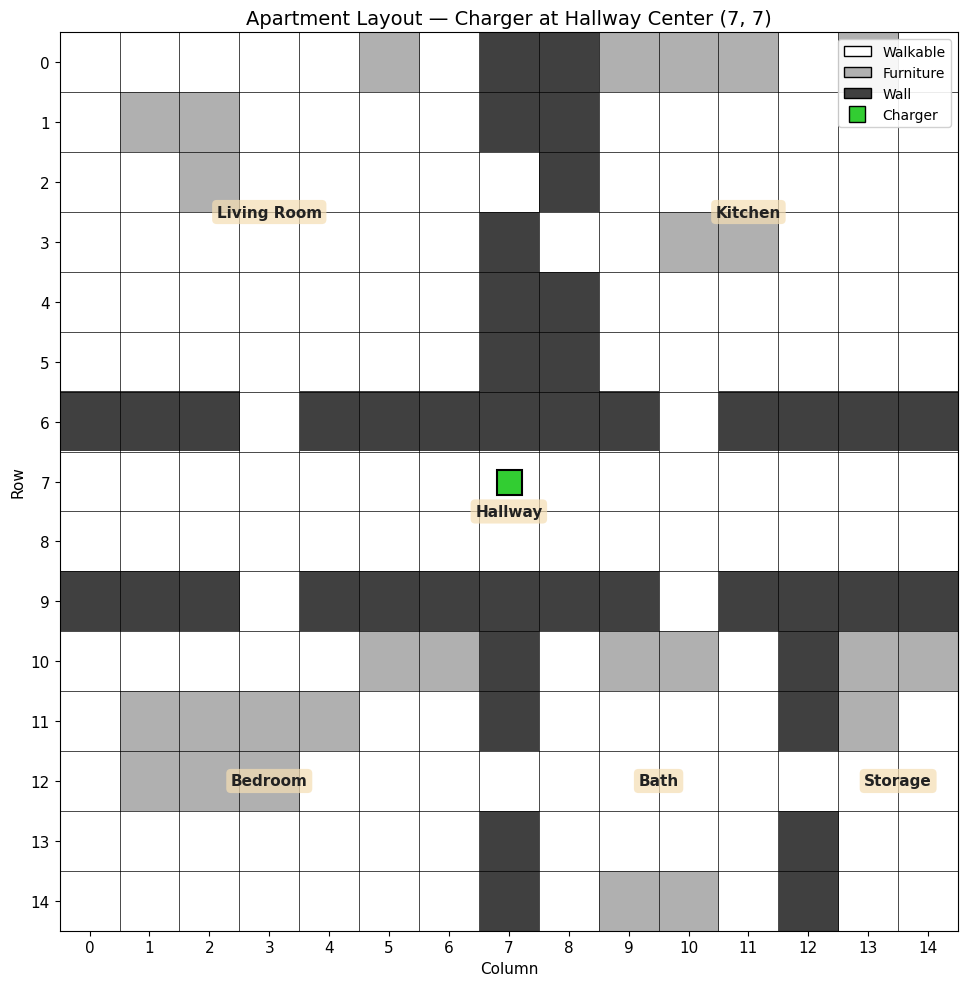

In [33]:
# Visualize the hallway-charger apartment layout
env_hallway = CleaningRobotEnv(PHASE2_HALLWAY_CONFIG)
env_hallway.reset(seed=42)

print(f'Phase 2 (Hallway Charger): {env_hallway}')
print(f'Charger position: {env_hallway.charger_pos}  (hallway center)')
print(f'Start position:   {env_hallway.charger_pos}')
print(f'Dirty tiles:      {env_hallway.total_dirty}')
print(f'State space:      {env_hallway.num_states}')
print()

fig, ax = plot_apartment_layout(env_hallway, figsize=(10, 10))
ax.set_title('Apartment Layout — Charger at Hallway Center (7, 7)', fontsize=14)
plt.show()

In [34]:
# Experiment 4: Same 4 configs on apartment with hallway charger
print('Running Experiment 4: Phase 2 Apartment (charger at hallway center)')
print(f'Training for {PHASE2_EPISODES} episodes x {len(SEEDS)} seeds each...\n')

exp4_results = {}
exp4_agents = {}

# Q-Learning + Epsilon-Greedy
print('Training Q-Learning + Epsilon-Greedy (hallway charger)...')
metrics, agents = run_experiment('qlearning', 'epsilon_greedy', config=PHASE2_HALLWAY_CONFIG, num_episodes=PHASE2_EPISODES)
exp4_results['Q-Learn + ε-Greedy'] = metrics
exp4_agents['Q-Learn + ε-Greedy'] = agents
print('  Done.')

# Q-Learning + UCB
print('Training Q-Learning + UCB (hallway charger)...')
metrics, agents = run_experiment('qlearning', 'ucb', config=PHASE2_HALLWAY_CONFIG, num_episodes=PHASE2_EPISODES)
exp4_results['Q-Learn + UCB'] = metrics
exp4_agents['Q-Learn + UCB'] = agents
print('  Done.')

# Q-Learning + Optimistic Init
print('Training Q-Learning + Optimistic (hallway charger)...')
metrics, agents = run_experiment('qlearning', 'optimistic', config=PHASE2_HALLWAY_CONFIG, num_episodes=PHASE2_EPISODES)
exp4_results['Q-Learn + Optimistic'] = metrics
exp4_agents['Q-Learn + Optimistic'] = agents
print('  Done.')

# SARSA + UCB
print('Training SARSA + UCB (hallway charger)...')
metrics, agents = run_experiment('sarsa', 'ucb', config=PHASE2_HALLWAY_CONFIG, num_episodes=PHASE2_EPISODES)
exp4_results['SARSA + UCB'] = metrics
exp4_agents['SARSA + UCB'] = agents
print('  Done.')

print('\nExperiment 4 complete!')

Running Experiment 4: Phase 2 Apartment (charger at hallway center)
Training for 10000 episodes x 5 seeds each...

Training Q-Learning + Epsilon-Greedy (hallway charger)...
  Done.
Training Q-Learning + UCB (hallway charger)...
  Done.
Training Q-Learning + Optimistic (hallway charger)...
  Done.
Training SARSA + UCB (hallway charger)...
  Done.

Experiment 4 complete!


### Experiment 4: Results

In [35]:
# Summary table
print('=== Experiment 4: Final Performance — Hallway Charger (last 500 episodes) ===\n')
summary_table(exp4_results, last_n=500)

=== Experiment 4: Final Performance — Hallway Charger (last 500 episodes) ===

Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learn + ε-Greedy                       303.6      23.3%    142.1    86.5%      5.7
Q-Learn + UCB                            315.7      22.5%    332.0    40.0%     27.0
Q-Learn + Optimistic                     267.2      21.3%    109.5    94.0%      3.1
SARSA + UCB                              397.9      28.3%    248.0    60.0%     12.0
-------------------------------------------------------------------------------------


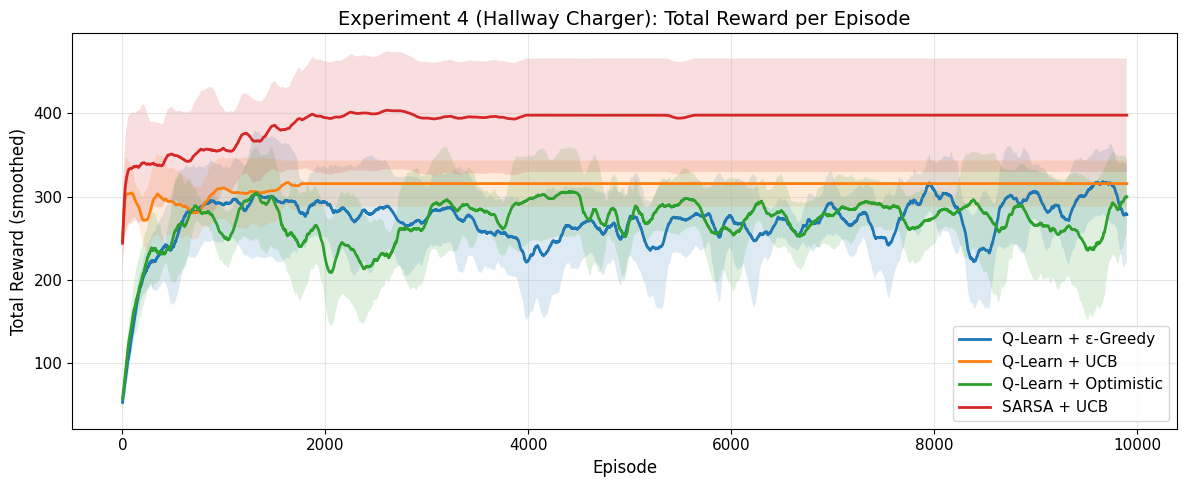

In [36]:
# Learning curves: reward
fig, ax = plot_learning_curves(
    exp4_results, metric='rewards', window=100,
    title='Experiment 4 (Hallway Charger): Total Reward per Episode',
    ylabel='Total Reward (smoothed)',
)
plt.show()

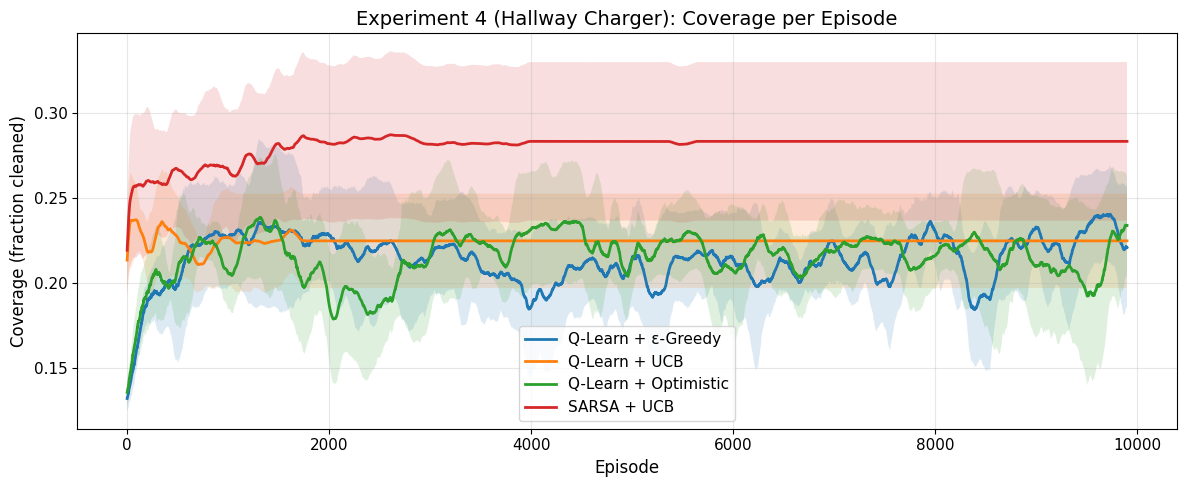

In [37]:
# Learning curves: coverage
fig, ax = plot_learning_curves(
    exp4_results, metric='coverages', window=100,
    title='Experiment 4 (Hallway Charger): Coverage per Episode',
    ylabel='Coverage (fraction cleaned)',
)
plt.show()

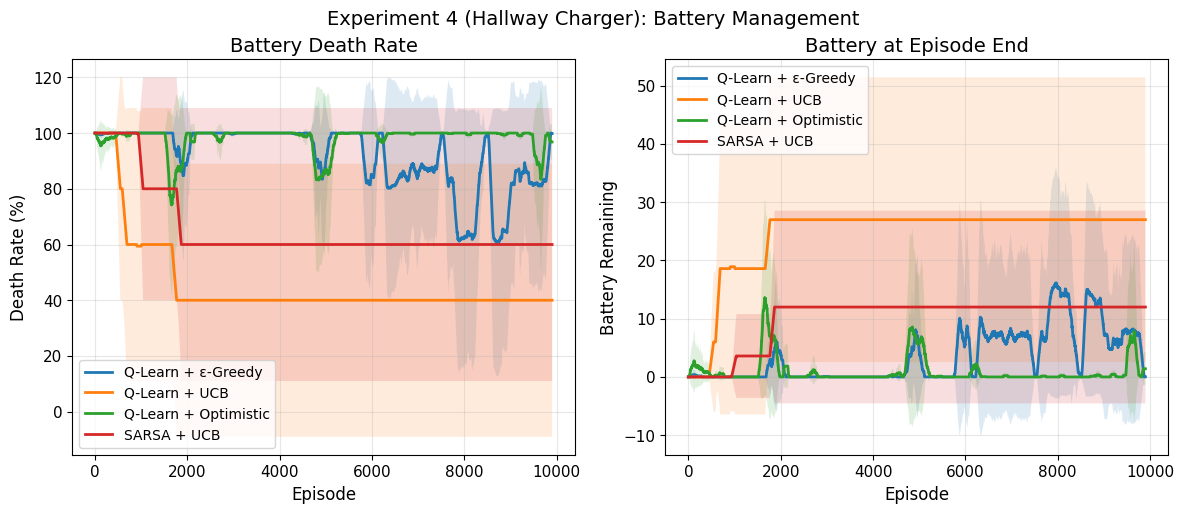

In [38]:
# Battery analysis
fig, axes = plot_battery_analysis(exp4_results, window=100)
fig.suptitle('Experiment 4 (Hallway Charger): Battery Management', fontsize=14, y=1.02)
plt.show()

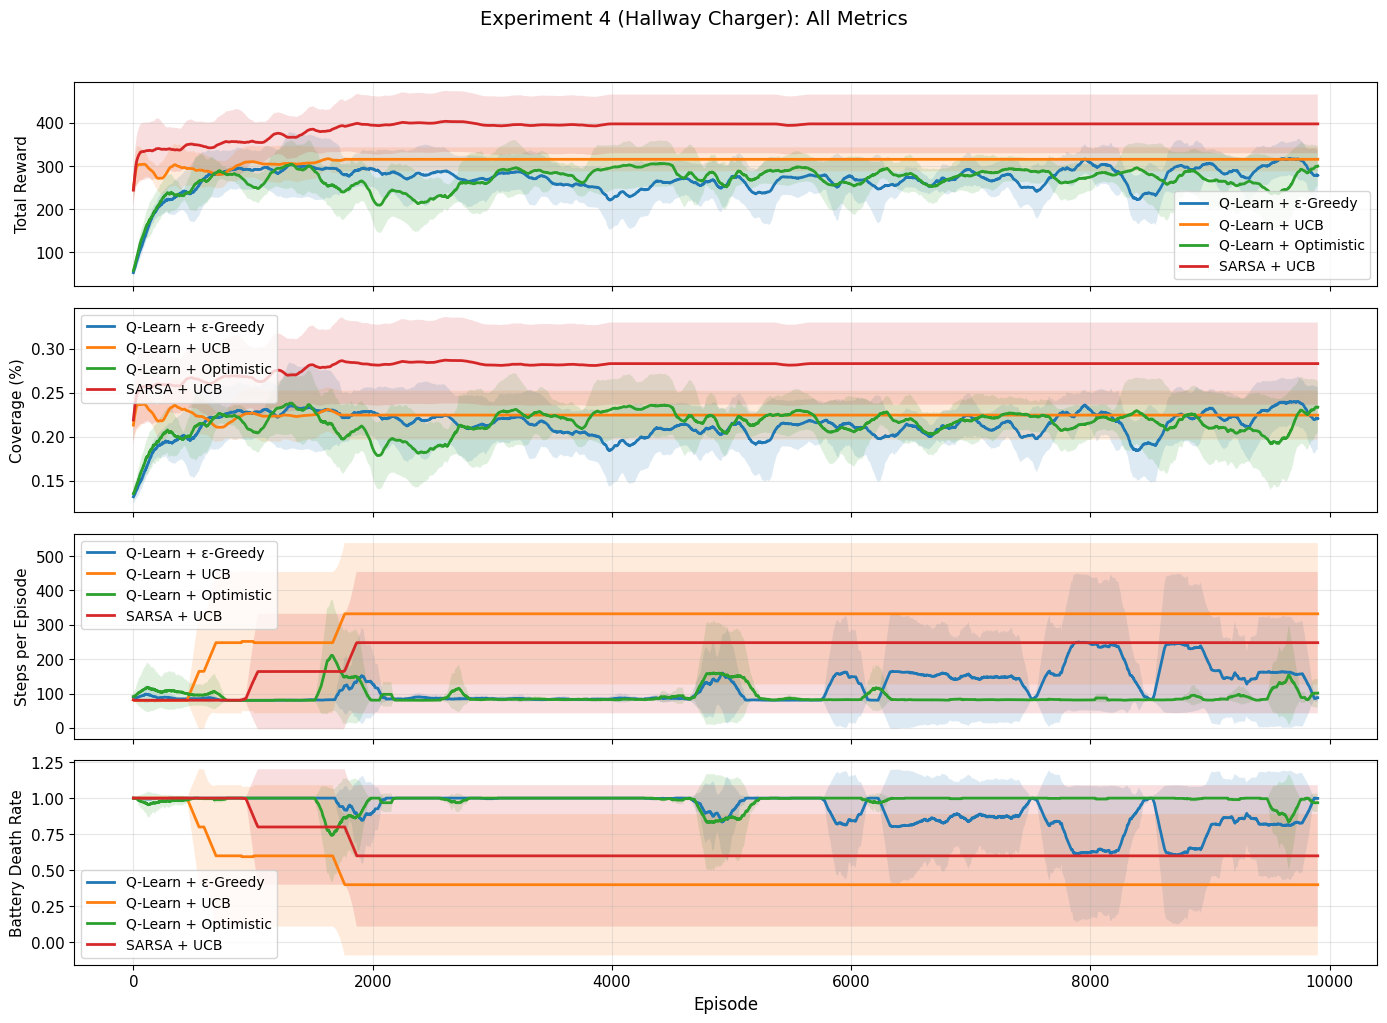

In [39]:
# Full multi-metric comparison
fig, axes = plot_multi_metric(exp4_results, window=100)
fig.suptitle('Experiment 4 (Hallway Charger): All Metrics', fontsize=14, y=1.02)
plt.show()

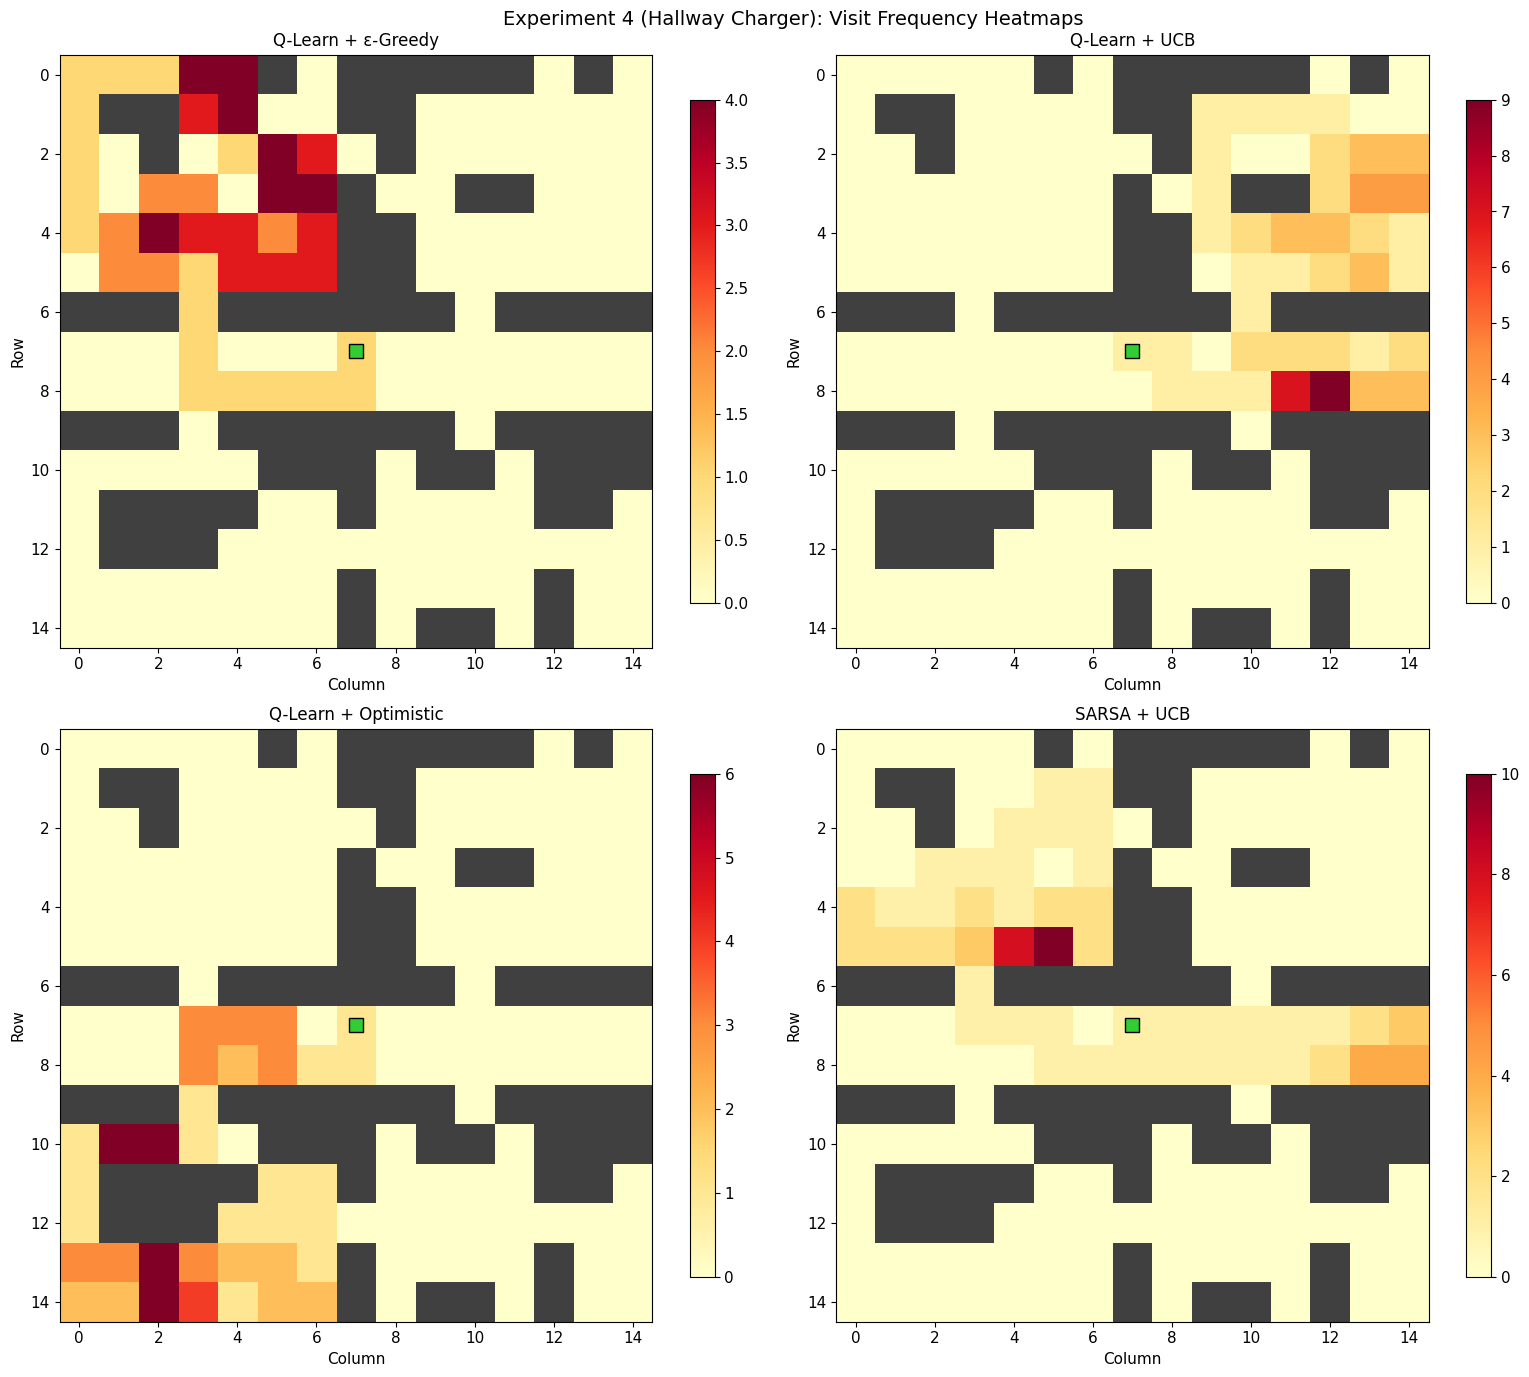

In [40]:
# Coverage heatmaps for all strategies — hallway charger
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for ax, (label, agents_list) in zip(axes_flat, exp4_agents.items()):
    env_eval = CleaningRobotEnv(PHASE2_HALLWAY_CONFIG)
    agent = agents_list[0]  # First seed's agent
    
    visit_counts = np.zeros((env_eval.rows, env_eval.cols))
    for ep in range(100):
        state = env_eval.reset(seed=7000 + ep)
        state_idx = env_eval.state_to_index(state)
        visit_counts[state[0], state[1]] += 1
        while not env_eval.done:
            action = agent.get_greedy_action(state_idx)
            next_state, _, done, _ = env_eval.step(action)
            state_idx = env_eval.state_to_index(next_state)
            visit_counts[next_state[0], next_state[1]] += 1
    
    visit_counts /= 100
    # Mask blocked tiles so they show as distinct
    masked = np.ma.array(visit_counts)
    for (r, c) in env_eval.blocked:
        masked[r, c] = np.ma.masked
    
    cmap = plt.cm.YlOrRd.copy()
    cmap.set_bad(color='#404040')  # Blocked tiles in dark gray
    
    im = ax.imshow(masked, cmap=cmap, origin='upper')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    cr, cc = env_eval.charger_pos
    ax.plot(cc, cr, 's', color='limegreen', markersize=10, markeredgecolor='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Experiment 4 (Hallway Charger): Visit Frequency Heatmaps', fontsize=14)
plt.tight_layout()
plt.show()

### Greedy Evaluation — Hallway Charger

In [41]:
# Greedy evaluation of hallway charger agents
eval_results_p2_hallway = {}

for label, agents_list in exp4_agents.items():
    env_eval = CleaningRobotEnv(PHASE2_HALLWAY_CONFIG)
    eval_metrics = evaluate_agent(env_eval, agents_list[0], num_episodes=200, seed=9999)
    eval_results_p2_hallway[label] = eval_metrics
    print(f'{label}: reward={np.mean(eval_metrics["rewards"]):.1f}, '
          f'coverage={np.mean(eval_metrics["coverages"])*100:.1f}%, '
          f'deaths={np.mean(eval_metrics["deaths"])*100:.0f}%')

Q-Learn + ε-Greedy: reward=315.8, coverage=24.0%, deaths=100%
Q-Learn + UCB: reward=315.8, coverage=24.0%, deaths=100%
Q-Learn + Optimistic: reward=285.5, coverage=22.1%, deaths=100%
SARSA + UCB: reward=386.5, coverage=28.6%, deaths=100%


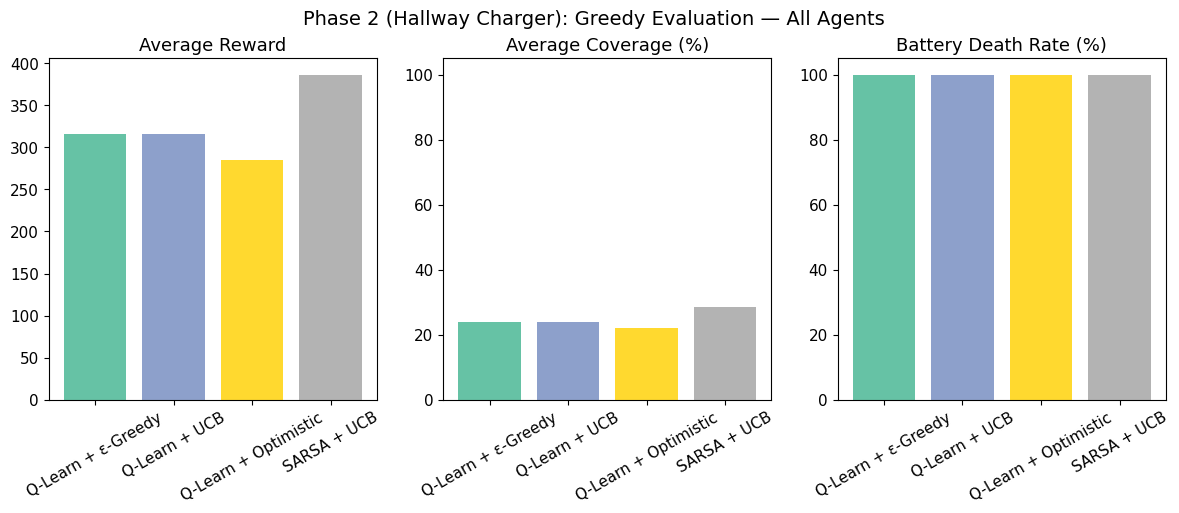

In [42]:
# Bar chart comparison — Hallway Charger
fig, axes = plot_evaluation_comparison(eval_results_p2_hallway)
fig.suptitle('Phase 2 (Hallway Charger): Greedy Evaluation — All Agents', fontsize=14, y=1.02)
plt.show()

### Charger Placement Comparison: Corner vs Hallway (Side-by-Side Heatmaps)

For the best strategy (SARSA + UCB), let's directly compare how charger placement affects exploration patterns.

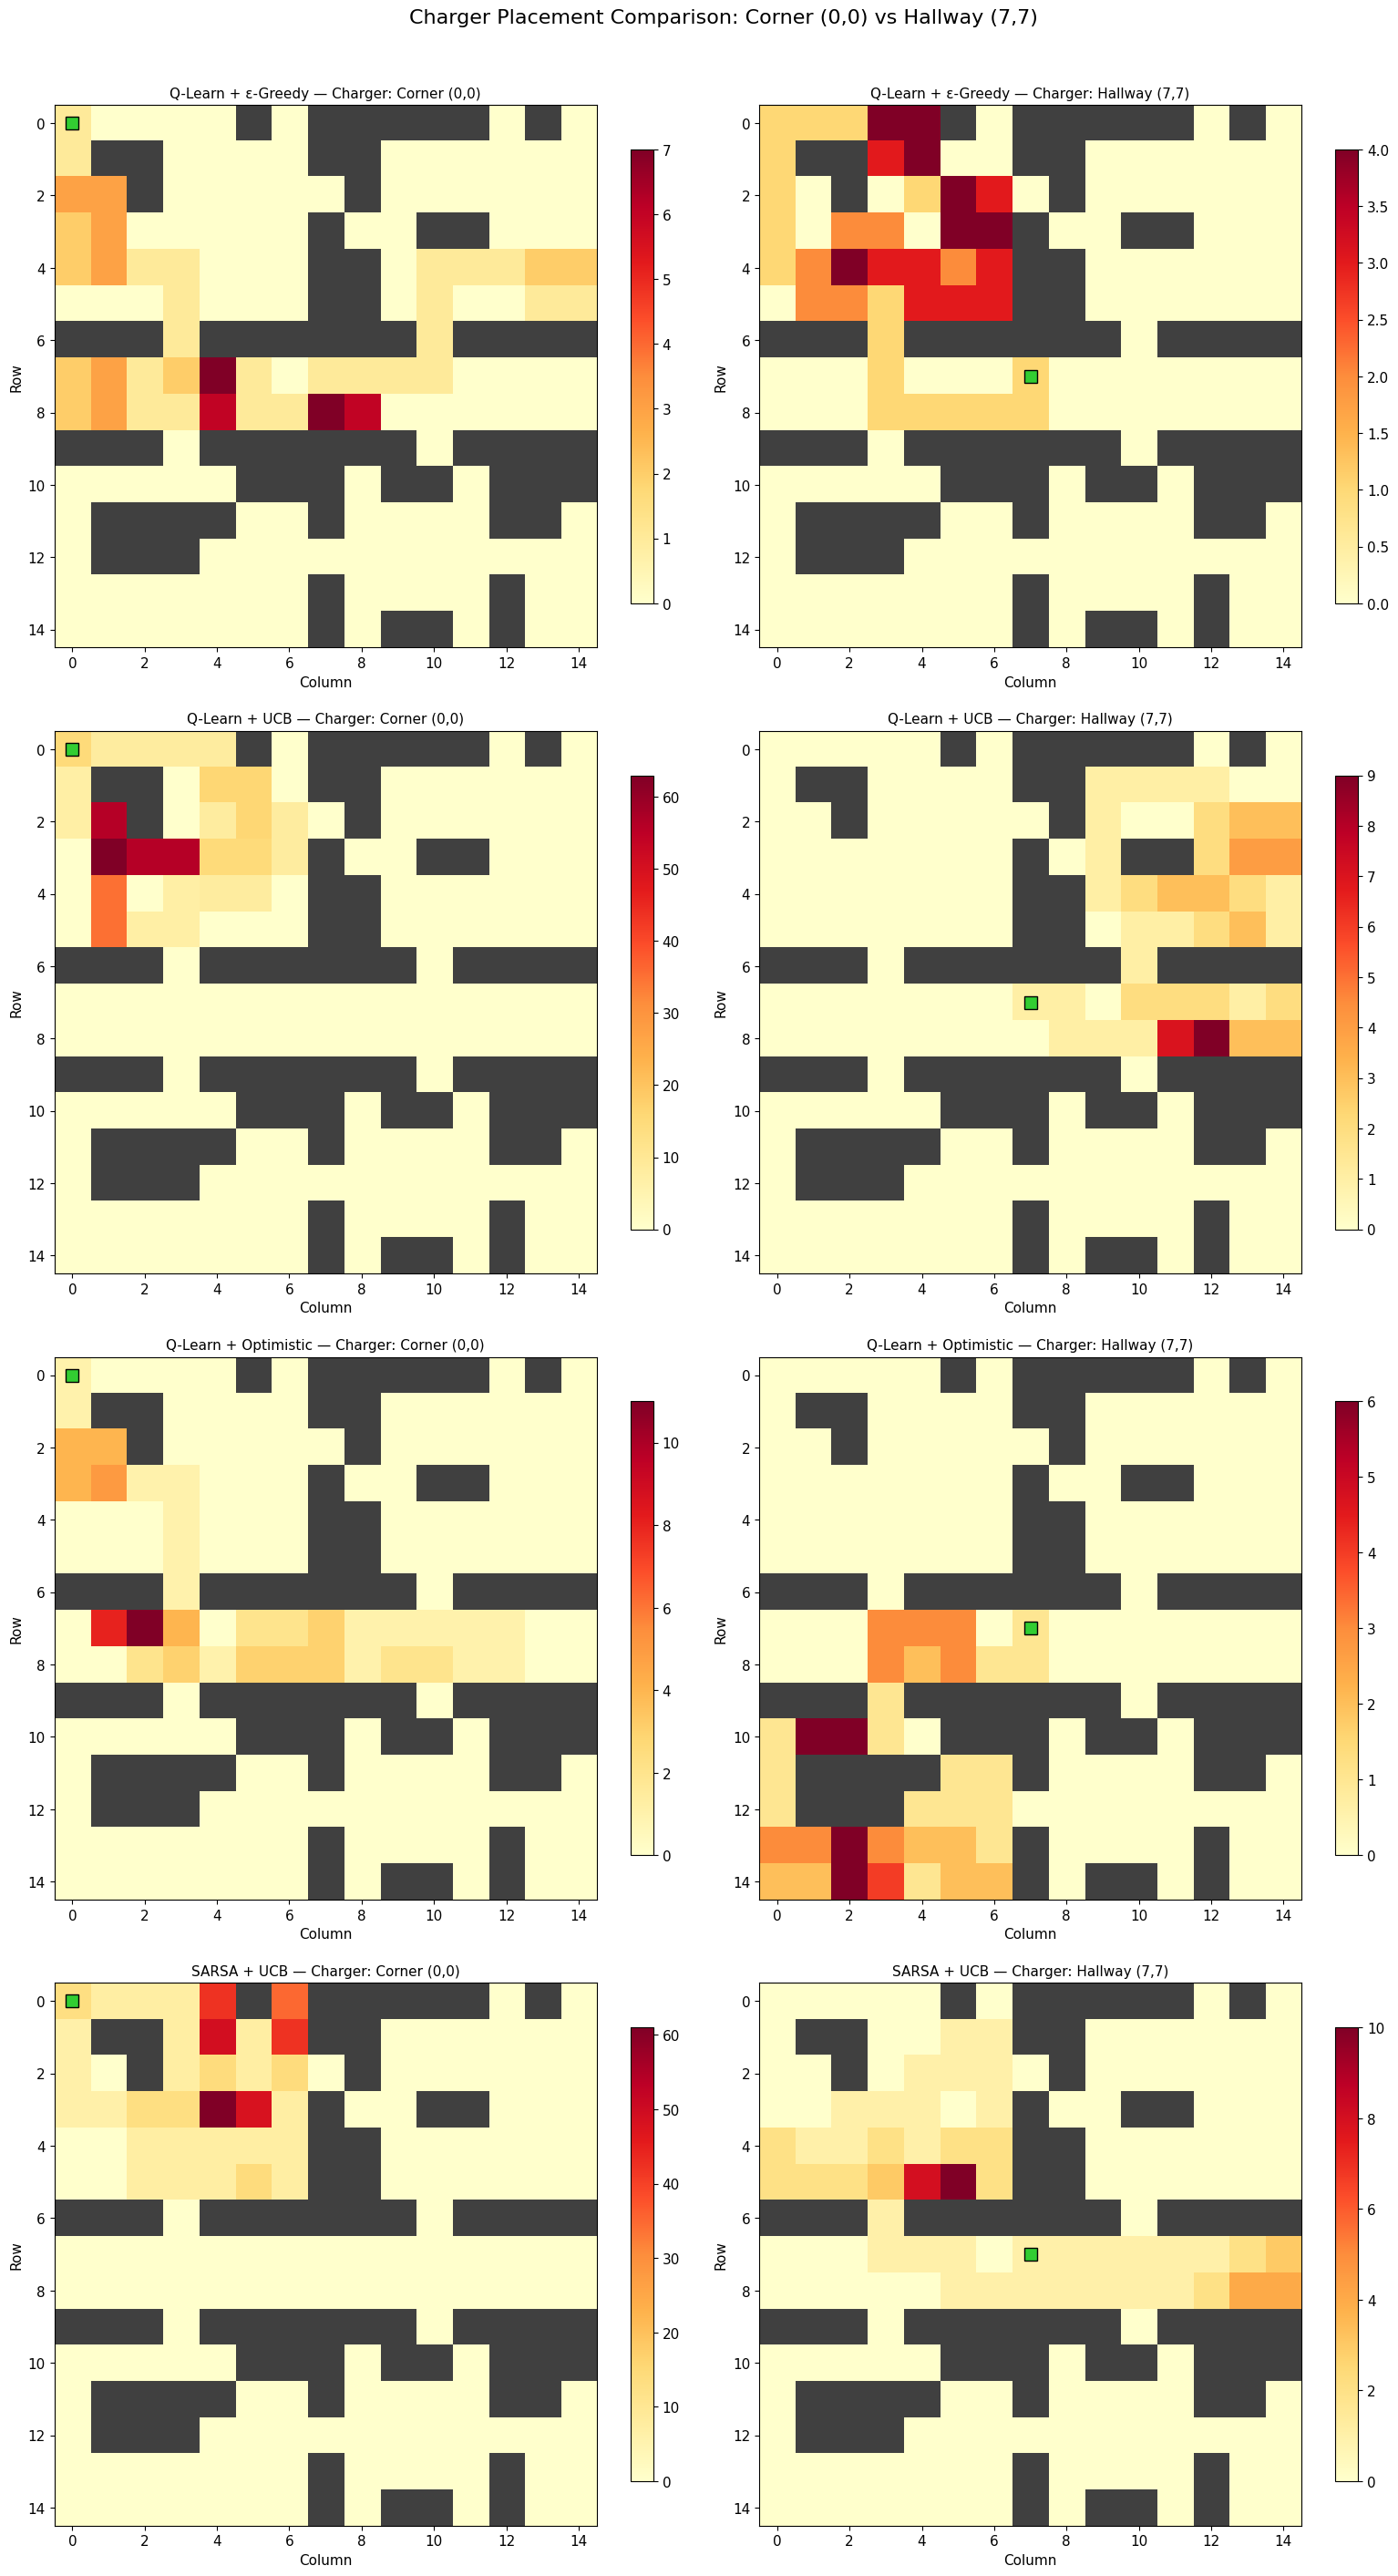

In [43]:
# Side-by-side heatmap: Corner vs Hallway for each strategy
strategies = list(exp3_agents.keys())  # same keys in both dicts

fig, axes = plt.subplots(len(strategies), 2, figsize=(16, 7 * len(strategies)))

for row, strategy in enumerate(strategies):
    for col, (config, agents_dict, charger_label) in enumerate([
        (PHASE2_CONFIG, exp3_agents, 'Corner (0,0)'),
        (PHASE2_HALLWAY_CONFIG, exp4_agents, 'Hallway (7,7)'),
    ]):
        ax = axes[row, col]
        env_eval = CleaningRobotEnv(config)
        agent = agents_dict[strategy][0]  # First seed
        
        visit_counts = np.zeros((env_eval.rows, env_eval.cols))
        for ep in range(100):
            state = env_eval.reset(seed=8000 + ep)
            state_idx = env_eval.state_to_index(state)
            visit_counts[state[0], state[1]] += 1
            while not env_eval.done:
                action = agent.get_greedy_action(state_idx)
                next_state, _, done, _ = env_eval.step(action)
                state_idx = env_eval.state_to_index(next_state)
                visit_counts[next_state[0], next_state[1]] += 1
        
        visit_counts /= 100
        masked = np.ma.array(visit_counts)
        for (r, c) in env_eval.blocked:
            masked[r, c] = np.ma.masked
        
        cmap = plt.cm.YlOrRd.copy()
        cmap.set_bad(color='#404040')
        
        im = ax.imshow(masked, cmap=cmap, origin='upper')
        ax.set_title(f'{strategy} — Charger: {charger_label}', fontsize=11)
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        cr, cc = env_eval.charger_pos
        ax.plot(cc, cr, 's', color='limegreen', markersize=10, markeredgecolor='black')
        plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Charger Placement Comparison: Corner (0,0) vs Hallway (7,7)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### Experiment 4: Analysis

**Question:** does moving the charger from the corner to the hallway center help?

Training (last 500 episodes):
- Coverage increases for ε-greedy (20.4% → 23.3%), and **SARSA + UCB** remains best on reward/coverage (28.3%).
- However, training death rates remain high for some agents.

Greedy evaluation (critical result):
- With the hallway charger, **all agents show 100% deaths in greedy evaluation**.

Interpretation:
- This is a clear example where **a change that should help (central charger) can change the learned objective in practice**.
- With the charger centrally placed, the agent can collect many +10 “clean_dirty” rewards without committing to a recharge routine; the learned greedy policy can devolve into **“clean-until-death”** behavior.
- It also reinforces that **training-time survival is not the same as learned-policy survival**, because exploration can mask a policy that fails without it.



---
### Phase 1 vs Phase 2: Full Comparison

Let's directly compare all configurations across both phases.

In [ ]:

print('=' * 90)
print('FULL COMPARISON: Phase 1 vs Phase 2 (Corner) vs Phase 2 (Hallway)')
print('Last 500 training episodes')
print('=' * 90)
print()
print('--- Phase 1 (10x10 open grid, battery=50, 99 dirty tiles, 5000 episodes) ---')
p1_summary = {}
p1_summary['Q-Learn + ε-Greedy'] = exp1_results['Q-Learning + ε-Greedy']
p1_summary['Q-Learn + UCB'] = exp1_results['Q-Learning + UCB']
p1_summary['Q-Learn + Optimistic'] = exp1_results['Q-Learning + Optimistic']
p1_summary['SARSA + UCB'] = exp2_results[sarsa_label]
summary_table(p1_summary, last_n=500)

print()
print('--- Phase 2: Corner Charger (15x15 apartment, battery=80, 154 dirty tiles, 10000 episodes) ---')
summary_table(exp3_results, last_n=500)

print()
print('--- Phase 2: Hallway Charger (15x15 apartment, battery=80, 154 dirty tiles, 10000 episodes) ---')
summary_table(exp4_results, last_n=500)

FULL COMPARISON: Phase 1 vs Phase 2 (Corner) vs Phase 2 (Hallway)
Last 500 training episodes

--- Phase 1 (10x10 open grid, battery=50, 99 dirty tiles, 5000 episodes) ---
Agent                                   Reward   Coverage    Steps   Death%  Battery
-------------------------------------------------------------------------------------
Q-Learn + ε-Greedy                       263.6      32.2%     50.4   100.0%      0.0
Q-Learn + UCB                            365.4      39.6%    230.0    60.0%     18.0
Q-Learn + Optimistic                     284.3      34.3%     50.1   100.0%      0.0
SARSA + UCB                              404.6      44.9%    140.0    80.0%      4.0
-------------------------------------------------------------------------------------

--- Phase 2: Corner Charger (15x15 apartment, battery=80, 154 dirty tiles, 10000 episodes) ---
Agent                                   Reward   Coverage    Steps   Death%  Battery
---------------------------------------------------